#   Traitement de données du fichier PDF  with Ref BC

In [1]:
import sys
import os

sys.path.append(os.path.abspath(os.path.join(os.path.dirname('__file__'), '/home/kduplat/Documents/Data/Pscript2/Fct_scripts')))
from Tools import *

L1 = read_parameters("/data1/DATA_Duplat/Brut/PDF/PD6n1")[0]
L2 = read_parameters("/data1/DATA_Duplat/Brut/PDF/PD6n1")[1]

lengthtab = L1 * L2
nbins = 100
Tnmin = np.array([5,8, 8,8,7,7,7, 8,8,8,8, 8, 8, 8,8])
Tnmax = np.array([80,45,50,50,50,50,50, 80,80,80,80,80,80,80])
fnb = np.arange(1,15)
folderpath = [f'/data1/DATA_Duplat/Brut/PDF/PD6n{nb}' for nb in fnb]
Tvar = [read_parameters(folder)[2] for folder in folderpath]


##  Size

In [6]:
def process_size(folder, Lengthtab, nmin, nmax):
    data = np.loadtxt(f"{folder}/stat_histosize.txt", comments = "#")
    
    last_non_zero = np.nonzero(data)[0]
    
    nbins = freedman_diaconis_log_bins(data)
    
    mean = np.sum(data * np.arange(len(data)))/np.sum(data)
    
    ndatafit, ndistloglog, nstat = mainfct(data, Lengthtab, nbins, nmin, nmax)
    Tndist = 10 ** ndistloglog
    Tndatafit = 10 ** ndatafit
    Tnstat = nstat[0]
    
    return Tndist, Tndatafit, Tnstat, last_non_zero[-1], mean, nbins


from scipy.integrate import quad

def numerator(x, a, b):
        return x * powerlaw(x, a, b)
    

In [7]:

results = Parallel(n_jobs=-1)(delayed(process_size)(folder, lengthtab, nmin, nmax)
                                  for (folder, nmin, nmax) in zip(folderpath, Tnmin, Tnmax))


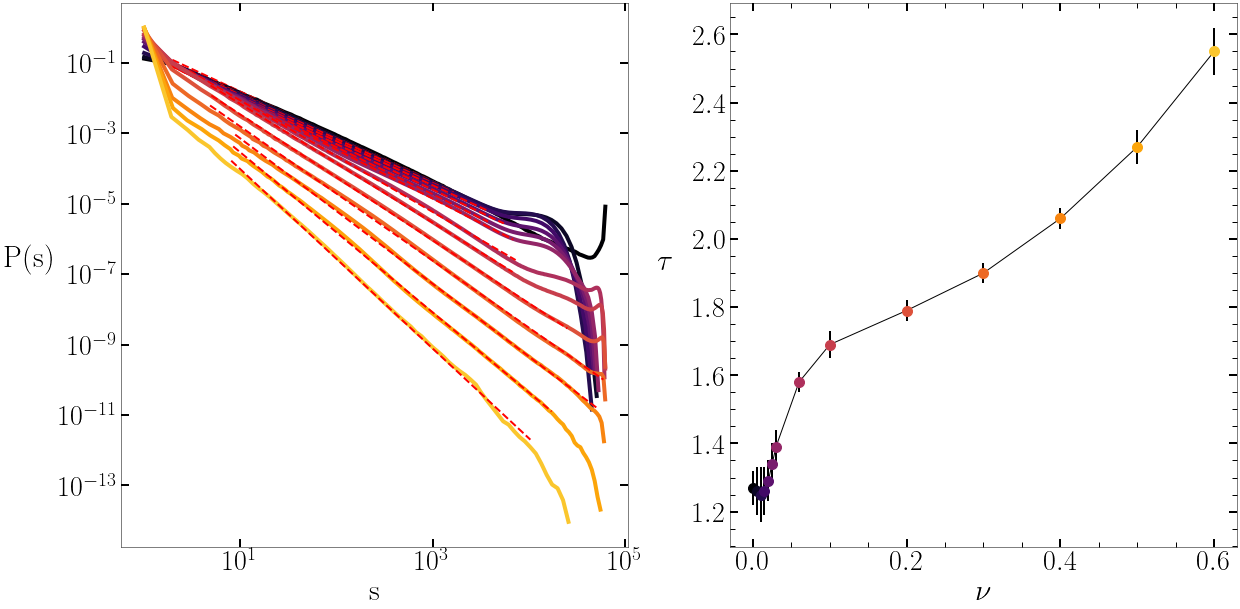

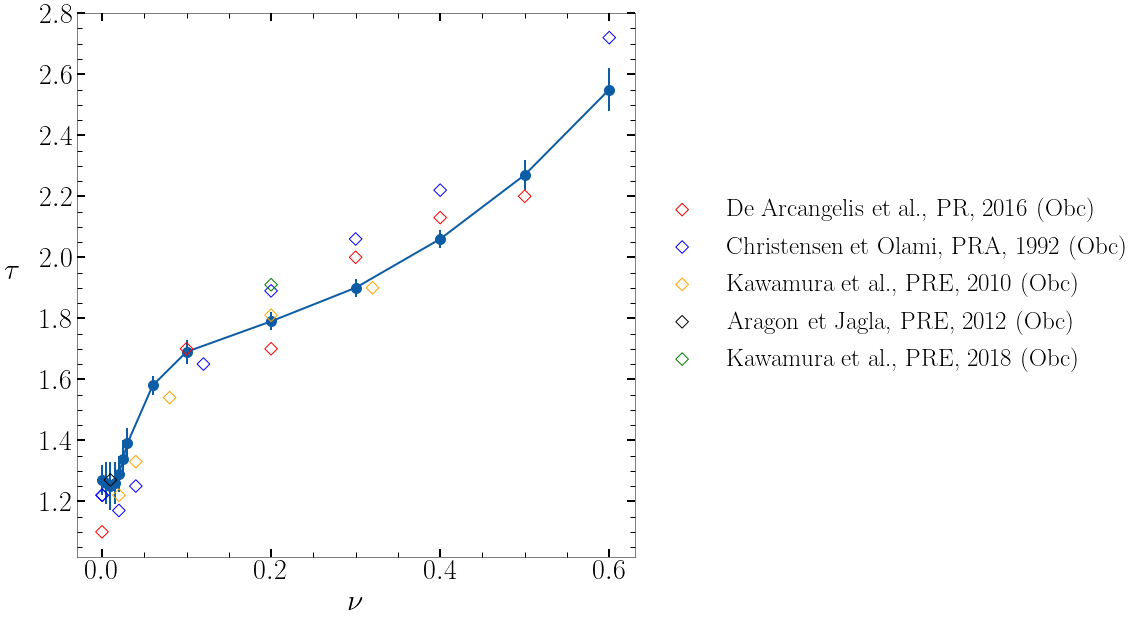

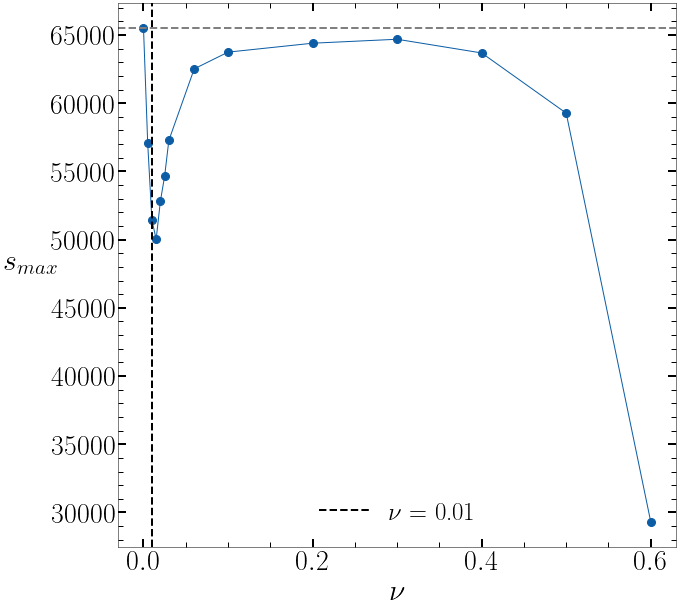

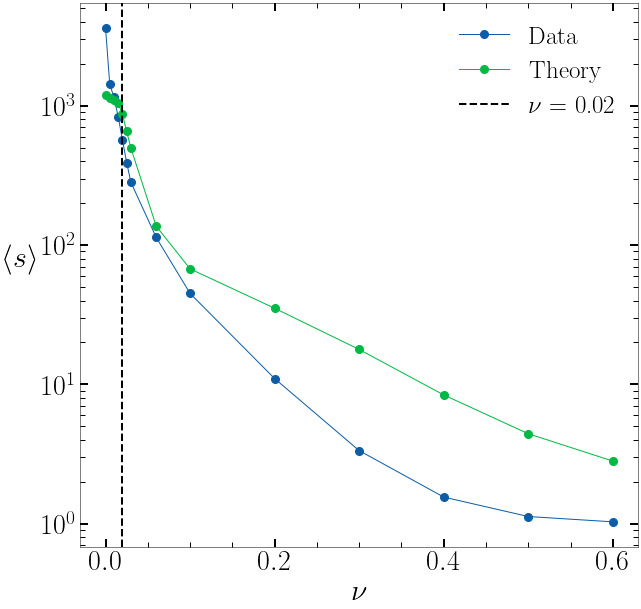

In [8]:
stop = [2.2e-6, 1e-5, 2e-5, 6e-6, 3e-6, 3e-6, 1e-6, 2e-7, 1e-7, 3e-9, 1e-10, 1e-11, 1e-11, 1e-12]
start_x = [1,1,1,1,1,1,1,2,4,4,4,8,8,8,8]

# Tndist_s = np.zeros((len(folderpath),nbins, 2))
Tnstat_s = np.zeros(len(folderpath))
Tnonzero_s = np.zeros(len(folderpath))
Tmean_s = np.zeros(len(folderpath))
Tndatafit_s = np.zeros((len(folderpath),2,2))
Tnbins_s = np.zeros(len(folderpath))

Ttau_s = np.zeros(len(folderpath))
Tperr_s = np.zeros(len(folderpath))
Tana_mean = np.zeros(len(folderpath))

NCURVES = len(folderpath) +1
cmap = plt.cm.get_cmap('inferno')
colors = [cmap(i / NCURVES) for i in range(NCURVES)]

plt.figure(figsize=(20,10))
ax1 = plt.subplot(1,2,1)
ax2 = plt.subplot(1,2,2)

for j, (Tndist_j, Tndatafit_j, Tnstat_j, Tnzero_j, mean_j, nbins_j) in enumerate(results[:]):
    # Tndist_s[j] = Tndist_j
    Tndatafit_s[j] = Tndatafit_j
    Tnstat_s[j] = Tnstat_j    
    Tnonzero_s[j] = Tnzero_j
    Tmean_s[j] = mean_j
    Tnbins_s[j] = nbins_j
    
    
    mask = Tndist_j[:,1] != 1
    filt_Tndist_j = Tndist_j[mask]
    
    ax1.plot(filt_Tndist_j[:,0],filt_Tndist_j[:,1], color = colors[j],
            linewidth=4, mfc="none", label = f"{Tvar[j]}\nb = {-Tnstat_s[j]:.2f}") 
    
    if Tvar[j] == 0.0:
        result, xs, _ , perr = fit_powerlaw(filt_Tndist_j[:,0], filt_Tndist_j[:,1], stop_x = 5e3, start_x = start_x[j], switch = 1,  plot=True, f_scale=1.0,
                                    function_to_fit='power')
    else:
        result, xs, _ , perr = fit_powerlaw(filt_Tndist_j[:,0], filt_Tndist_j[:,1], n_cutoff = stop[j], start_x = start_x[j], plot=True, f_scale=1.0,
                                    function_to_fit='power')
    
    Ttau_s[j] = np.round(result.x[1], 2)
    Tperr_s[j] =  np.round(perr[1], 2)
    ax1.plot(xs, powerlaw(xs, *result.x), 'r--', lw = 2, label='$a={} \pm {}$'.format(np.round(result.x[1], 2),
                                                                         np.round(perr[1], 2)))
    ax2.errorbar(Tvar[j], - np.round(result.x[1], 2), yerr = np.round(perr[1], 2), fmt = 'o', color = colors[j], ecolor='black', lw =2, markersize = 10)
    
    ##### Find the analytique mean of the powerlaw integral( x*ax**b)/integral(ax**b)##### 
    s_min = 1
    s_max = max(Tndist_j[:,0][mask])
    
    # numerator_integral, _ = quad(numerator, s_min, s_max, args=(result_final.x[0], result_final.x[1]))
    # denominator_integral, _ = quad(powerlaw, s_min, s_max, args=(result_final.x[0], result_final.x[1]))
    
    numerator_integral, _ = quad(numerator, s_min, s_max, args=(result.x[0], result.x[1]))
    denominator_integral, _ = quad(powerlaw, s_min, s_max, args=(result.x[0], result.x[1]))
    
    Tana_mean[j] =  numerator_integral / denominator_integral
    
    # Calcul des CDFs
    
    findex = (np.abs(filt_Tndist_j[:,0] - xs[-1])).argmin()
    bindex = start_x[j]
    
    lim_Tndist_j = filt_Tndist_j[bindex:findex]
    observed_cdf = np.cumsum(lim_Tndist_j[:-1,1] * np.diff(lim_Tndist_j[:,0]))  # Observé
    
    observed_cdf /= observed_cdf[-1]  # Normalisation

    theoretical_cdf = np.cumsum(powerlaw(xs[:-1], *result.x) * np.diff(xs))  # Théorique
    theoretical_cdf /= theoretical_cdf[-1]  # Normalisation
    ks_statistic, p_value = ks_2samp(observed_cdf, theoretical_cdf)

    if ks_statistic > 0.1 or p_value < 0.05:
        print(f"nu = {Tvar[j]}")
        print(f"Statistique KS: {ks_statistic}")
        print(f"p-value: {p_value}")
        
ax2.plot(Tvar, -Ttau_s, linestyle = '-', c = 'k', zorder=1)       
                
ax1.set_xscale("log")
ax1.set_yscale("log")
ax1.set_xlabel('s', fontsize=30)
ax1.set_ylabel('P(s) ', fontsize=30, rotation = 0, labelpad = 30)
ax1.tick_params(labelsize = 28,length = 8, width = 2)
ax1.tick_params(labelsize = 28,length = 5, width = 1, which = 'minor')

ax2.set_xlabel(r'$\nu$', fontsize=30)
ax2.set_ylabel(r'$\tau$', fontsize=30, rotation = 0, labelpad = 30)
ax2.tick_params(labelsize = 28,length = 8, width = 2)
ax2.tick_params(labelsize = 28,length = 5, width = 1, which = 'minor')
""" plt.legend(title_fontsize = 23, ncol = 2, loc='center left', bbox_to_anchor=(1, 0.5),fontsize = 25) """
plt.show()

#######With the litterature #######
Arcangelis_nu = [0,0.1,  0.2, 0.3, 0.4, 0.5]
Arcangelis_slope = [1.1, 1.7 ,1.7, 2.0, 2.13, 2.20]

Chris_Olami_nu = [0, 4e-4, 0.02, 0.04, 0.12, 0.2, 0.3, 0.4, 0.6]
Chris_Olami_slope = [1.22, 1.22, 1.17, 1.25, 1.65, 1.89, 2.06, 2.22, 2.72]

Kawamura_nu = [0.02, 0.04, 0.08, 0.2, 0.32]
Kawamura_slope = [1.22,1.33,1.54,1.81,1.90]

Aragon_nu = [0.01] #OFC*, pente supposé constante
Aragon_slope = [1.27]  

Wissel_nu = [0.2]
Wissel_slope = [1.91]

plt.figure(figsize=(10,10))
plt.errorbar(Tvar, - Ttau_s, yerr = Tperr_s, fmt = '-o', lw =2, markersize = 10, zorder= -1)
plt.scatter(Arcangelis_nu, Arcangelis_slope, facecolors = 'none', color = 'r', marker = 'D',s = 80, lw = 1, label = 'De Arcangelis et al., PR, 2016 (Obc)')
plt.scatter(Chris_Olami_nu, Chris_Olami_slope, facecolors = 'none', color = 'b', marker = 'D',s = 80, lw = 1, label = 'Christensen et Olami, PRA, 1992 (Obc)')
plt.scatter(Kawamura_nu, Kawamura_slope, facecolors = 'none', color = 'orange', marker = 'D',s = 80, lw = 1, label = 'Kawamura et al., PRE, 2010 (Obc)')
plt.scatter(Aragon_nu, Aragon_slope, facecolors = 'none', color = 'k', marker = 'D',s = 80, lw = 1, label = 'Aragon et Jagla, PRE, 2012 (Obc)')
plt.scatter(Wissel_nu, Wissel_slope, facecolors = 'none', color = 'g', marker = 'D',s = 80, lw = 1, label = 'Kawamura et al., PRE, 2018 (Obc)')
plt.xlabel(r'$\nu$', fontsize=30)
plt.ylabel(r'$\tau$', fontsize=30, rotation = 0, labelpad = 30)
plt.tick_params(labelsize = 28,length = 8, width = 2)
plt.tick_params(labelsize = 28,length = 5, width = 1, which = 'minor')
plt.legend(title_fontsize = 23, ncol = 1, loc='center left', bbox_to_anchor=(1, 0.5),fontsize = 25)
plt.show()

#######S_max#######
plt.figure(figsize = (10,10))
plt.plot(Tvar, Tnonzero_s, markersize = 8, marker = 'o')
plt.axvline(Tvar[2], lw = 2, ls = '--', c = 'k', label = "{} = {}".format(macros['diss'], Tvar[2]))
plt.axhline(L1 * L2, c = "grey", lw = 2, ls = '--')
plt.xlabel(r'$\nu$', fontsize=30)
plt.ylabel(r'$s_{max}$', fontsize = 30, rotation = 0,labelpad= 20)
plt.tick_params(labelsize = 28,length = 8, width = 2)
plt.tick_params(labelsize = 28,length = 5, width = 1, which = 'minor')
plt.legend(fontsize = 25)
plt.show()
#######S_mean#######


plt.figure(figsize = (10,10))
ax2 = plt.subplot(1,1,1)

ax2.plot(Tvar, Tmean_s, markersize = 8, marker = 'o', label = "Data")
ax2.plot(Tvar, Tana_mean, markersize = 8, marker = 'o', label = "Theory")
ax2.axvline(Tvar[4], lw = 2, ls = '--', c = 'k', label = "{} = {}".format(macros['diss'], Tvar[4]))
ax2.set_xlabel(r'$\nu$', fontsize=30)
ax2.set_ylabel(r'$\langle s \rangle$', fontsize = 30, rotation = 0,labelpad= 20)
ax2.tick_params(labelsize = 28,length = 8, width = 2)
ax2.tick_params(labelsize = 28,length = 5, width = 1, which = 'minor')
ax2.set_yscale("log")
plt.legend(fontsize = 25)

plt.show()

In [2]:
Tndist_s, Tndatafit_s, Tnstat_s, Tnonzero_s, Tmean_s, Tnbins_s = np.array(Parallel(n_jobs=-1)(delayed(process_size_from_histo)(folder, lengthtab, nmin, nmax)
                                                                    for (folder, nmin, nmax) in zip(folderpath, Tnmin, Tnmax))).T

<ipython-input-2-51439b92fb5d>:1: VisibleDeprecationWarning: Creating an ndarray from ragged nested sequences (which is a list-or-tuple of lists-or-tuples-or ndarrays with different lengths or shapes) is deprecated. If you meant to do this, you must specify 'dtype=object' when creating the ndarray.
  Tndist_s, Tndatafit_s, Tnstat_s, Tnonzero_s, Tmean_s, Tnbins_s = np.array(Parallel(n_jobs=-1)(delayed(process_size_from_histo)(folder, lengthtab, nmin, nmax)


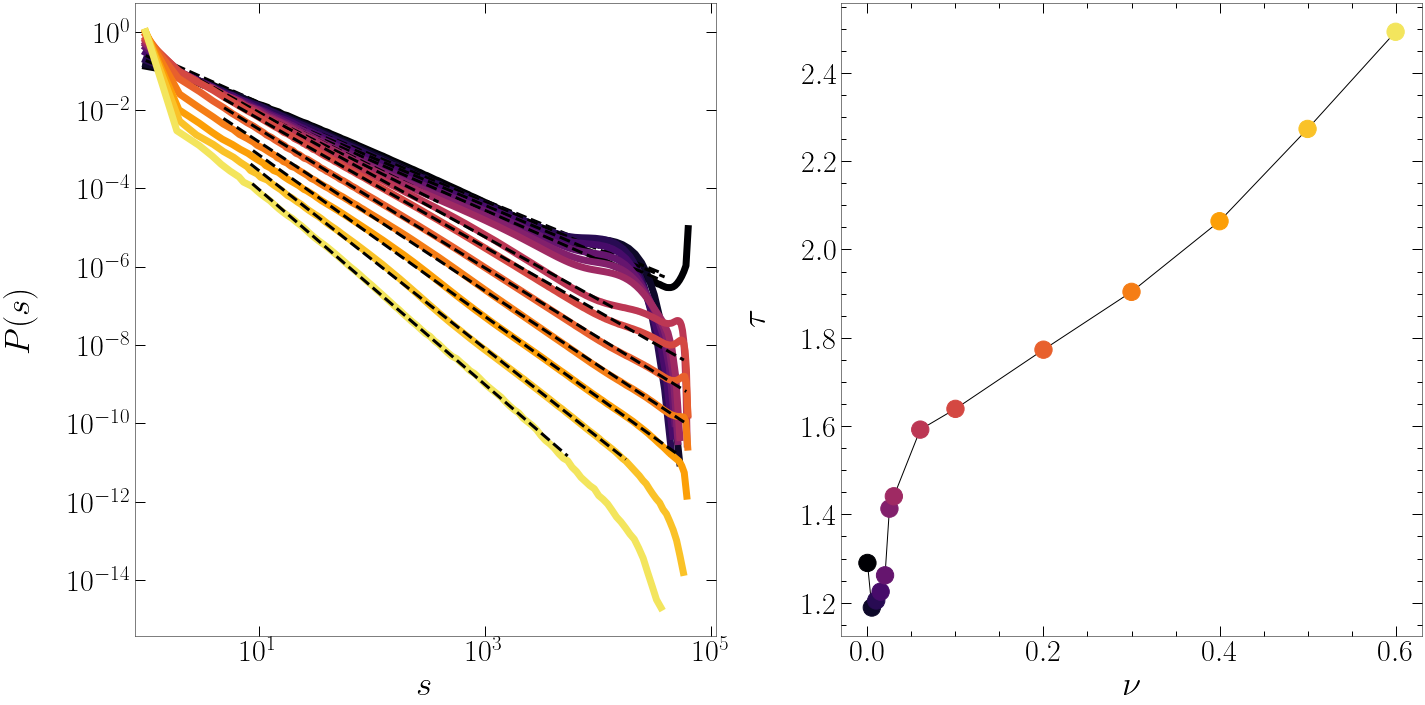

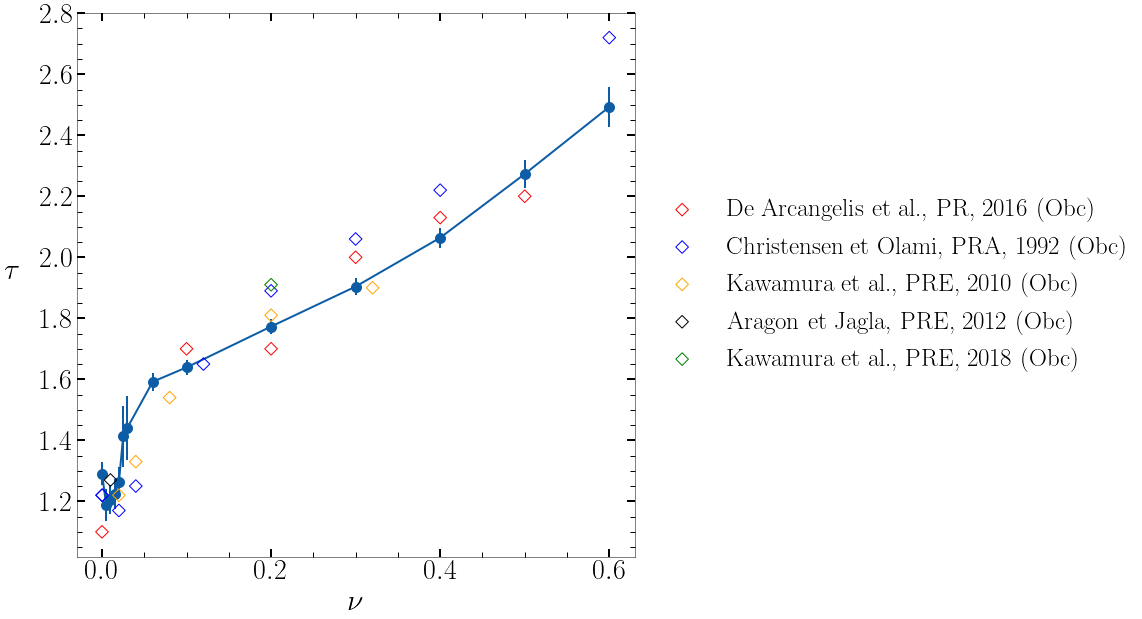

[65536 60091 51436 52529 53521 55982 57324 62913 63741 64529 64685 64231
 60894 39411]


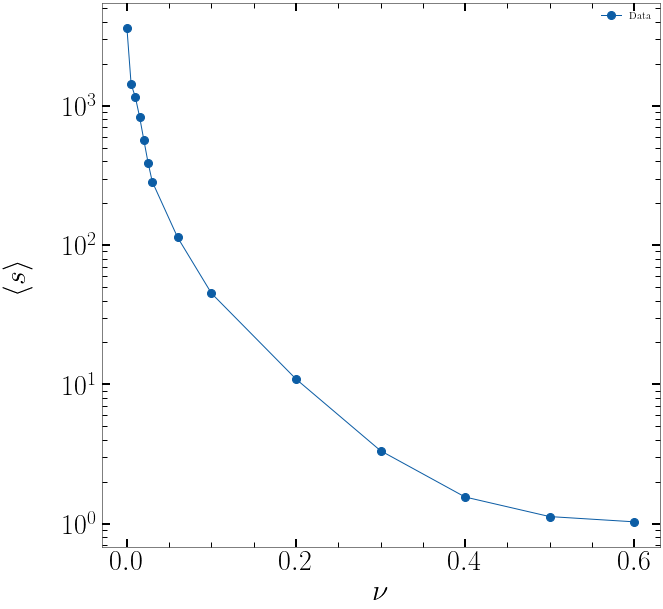

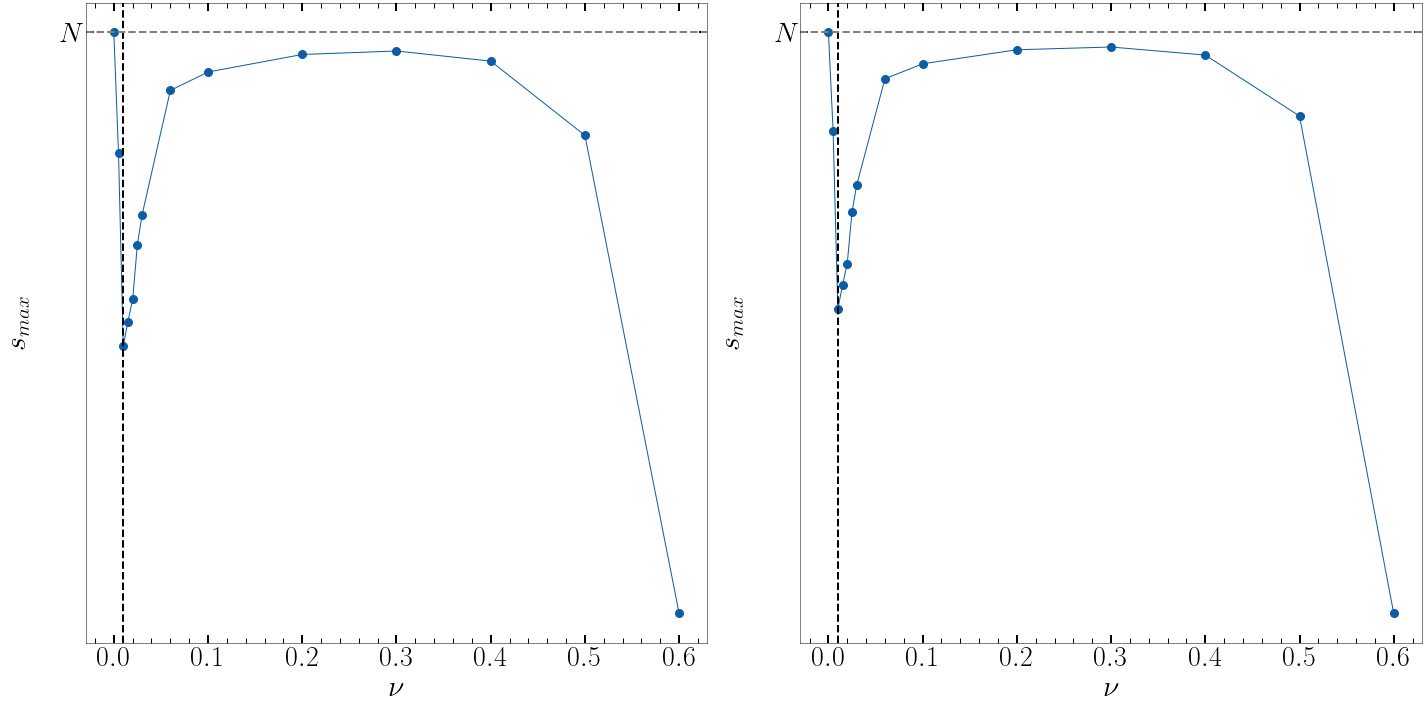

In [4]:
Tstop_x = [1.e4, 1e-8, 1e-10, 1e-8, 1e-6,5e-5,5e-5,1e-7, 1e-8, 1e-9, 1e-10, 1e-11, 1e-11, 1e-11]
Tstart_x = [0,4,0,1,1,0,1,2,4,4,4,8,8,8,8]

NCURVES = len(Tvar)

colors = [plt.cm.get_cmap('inferno')(i/NCURVES) for i in range(NCURVES)]

Thisto_s, Txfit_s, Tyfit_s, Ttau_s, Tperr_s = PDF_s_histogram(Tndist_s, Tstart_x, Tstop_x, Tvar)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize = (20,10))
for i, (histo, xfit, yfit, tau, nu) in enumerate(zip(Thisto_s, Txfit_s, Tyfit_s, Ttau_s, Tvar)):
    ax1.plot(histo[:,0],histo[:,1], color = colors[i],linewidth=7, label = f"{nu}\nb = {-Tnstat_s[i]:.2f}")
    ax1.plot(xfit, yfit, 'k--', lw = 3)

ax2.plot(Tvar, -Ttau_s, linestyle = '-', c = 'k', zorder=1)

ax1.set_xticks([1e0, 1e1, 1e2, 1e3, 1e4, 1e5])
ax1.set_xlim(0.8,1.1e5)
ax2.scatter(Tvar, -Ttau_s, color = colors[:], zorder=2, marker = 'o', s = 300)
       

para_fig(ax1, r'$s$', r'$P(s)$', type = 'loglog', labelsize = 35, tickssize= 30, width_M = 1, length_M = 10)
para_fig(ax2, r'$\nu$', r'$\tau$', type = 'lin', labelsize = 35, tickssize= 30, width_M = 1, length_M = 10)
plt.tight_layout()
plt.show()

#######With the litterature #######
Arcangelis_nu = [0,0.1,  0.2, 0.3, 0.4, 0.5]
Arcangelis_slope = [1.1, 1.7 ,1.7, 2.0, 2.13, 2.20]

Chris_Olami_nu = [0, 4e-4, 0.02, 0.04, 0.12, 0.2, 0.3, 0.4, 0.6]
Chris_Olami_slope = [1.22, 1.22, 1.17, 1.25, 1.65, 1.89, 2.06, 2.22, 2.72]

Kawamura_nu = [0.02, 0.04, 0.08, 0.2, 0.32]
Kawamura_slope = [1.22,1.33,1.54,1.81,1.90]

Aragon_nu = [0.01] #OFC*, pente supposé constante
Aragon_slope = [1.27]  

Wissel_nu = [0.2]
Wissel_slope = [1.91]

plt.figure(figsize=(10,10))
plt.errorbar(Tvar, - Ttau_s, yerr = Tperr_s, fmt = '-o', lw =2, markersize = 10, zorder= -1)
plt.scatter(Arcangelis_nu, Arcangelis_slope, facecolors = 'none', color = 'r', marker = 'D',s = 80, lw = 1, label = 'De Arcangelis et al., PR, 2016 (Obc)')
plt.scatter(Chris_Olami_nu, Chris_Olami_slope, facecolors = 'none', color = 'b', marker = 'D',s = 80, lw = 1, label = 'Christensen et Olami, PRA, 1992 (Obc)')
plt.scatter(Kawamura_nu, Kawamura_slope, facecolors = 'none', color = 'orange', marker = 'D',s = 80, lw = 1, label = 'Kawamura et al., PRE, 2010 (Obc)')
plt.scatter(Aragon_nu, Aragon_slope, facecolors = 'none', color = 'k', marker = 'D',s = 80, lw = 1, label = 'Aragon et Jagla, PRE, 2012 (Obc)')
plt.scatter(Wissel_nu, Wissel_slope, facecolors = 'none', color = 'g', marker = 'D',s = 80, lw = 1, label = 'Kawamura et al., PRE, 2018 (Obc)')
plt.xlabel(r'$\nu$', fontsize=30)
plt.ylabel(r'$\tau$', fontsize=30, rotation = 0, labelpad = 30)
plt.tick_params(labelsize = 28,length = 8, width = 2)
plt.tick_params(labelsize = 28,length = 5, width = 1, which = 'minor')
plt.legend(title_fontsize = 23, ncol = 1, loc='center left', bbox_to_anchor=(1, 0.5),fontsize = 25)
plt.show()


####### MEAN SIZE ########
fig, ax = plt.subplots(figsize=(10,10))
ax.plot(Tvar, Tmean_s, markersize = 8, marker = 'o', label = "Data")
# ax.plot(Tvar, Tana_mean, markersize = 8, marker = 'o', label = "Theory")
# ax.axvline(Tvar[4], lw = 2, ls = '--', c = 'k', label = "{} = {}".format(macros['diss'], Tvar[4]))
para_fig(ax, r'$\nu$', r'$\langle s \rangle$', type = 'semilog')
plt.legend()

from matplotlib.ticker import FixedLocator, NullLocator
####### MAX SIZE ########
N = L1*L2

fig, ax = plt.subplots(1,2, figsize = (20,10))
ax[0].plot(Tvar, Tnonzero_s, markersize = 8, marker = 'o')
ax[0].axvline(Tvar[2], lw = 2, ls = '--', c = 'k', label = "{} = {}".format(macros['diss'], Tvar[2]))
# ax[0].axhline(L1 * L2, c = "grey", lw = 2, ls = '--')
ax[0].axhline(N, c = "grey", lw = 2, ls = '--')

ax[1].plot(Tvar, Tnonzero_s, markersize = 8, marker = 'o')
ax[1].axvline(Tvar[2], lw = 2, ls = '--', c = 'k', label = "{} = {}".format(macros['diss'], Tvar[2]))
# ax[1].axhline(L1 * L2, c = "grey", lw = 2, ls = '--')
ax[1].axhline(N, c = "grey", lw = 2, ls = '--')


para_fig(ax[0], r'$\nu$', r'$s_{max}$',)
para_fig(ax[1], r'$\nu$', r'$s_{max}$',type = 'semilog')


yticks = [N, N/2, N/4]
ax[0].yaxis.set_major_locator(FixedLocator(yticks))  # Supprime tous les autres ticks majeurs
ax[0].yaxis.set_minor_locator(NullLocator())  # Supprime les ticks mineurs
ax[0].set_yticklabels([r'$N$', r'$N / 2$', r'$N / 4$'])
ax[1].yaxis.set_major_locator(FixedLocator(yticks))  # Supprime tous les autres ticks majeurs
ax[1].yaxis.set_minor_locator(NullLocator())  # Supprime les ticks mineurs
ax[1].set_yticklabels([r'$N$', r'$N / 2$', r'$N / 4$'])

print(Tnonzero_s)

plt.tight_layout()
plt.show()


###     We want to know the number of avalanche necessary in the case $\nu = 0.6$

In [6]:
lengthtab = L1 * L2
nbins = 100

data = np.loadtxt(f"/data1/DATA_Duplat/Brut/PDF/PD5n12/stat_histosize.txt", comments = "#") #load linear histogram
last_non_zero = np.nonzero(data)[0]

nbins = 100
log_bins = np.logspace(np.log10(1), np.log10(len(data)), nbins + 1)
log_histo = np.zeros(nbins)
lin_bins = np.arange(0, len(data))
# print(linbins)

norm_data = data/np.sum(data)
for i in range(len(log_bins) - 1): #Take the lin histo and turn it into a log histo
    # Trouver les bins linéaires qui chevauchent le bin logarithmique courant
    overlap = (lin_bins >= log_bins[i]) & (lin_bins < log_bins[i + 1])
    # Ajouter les comptages de ces bins linéaires au bin logarithmique
    if len(norm_data[overlap])!=0:
        log_histo[i] = np.sum(norm_data[overlap])/len(norm_data[overlap])

    
    
# Renorm the histogram
bin_widths = np.diff(log_bins)  # Largeur de chaque bin logarithmique
area = np.sum(log_histo * bin_widths)  # Calcul de l'aire sous la courbe
log_histo_normalized = log_histo / area  # Normalisation

mask2 = log_histo_normalized != 0
mask3 = log_histo != 0

log_y = np.log(log_histo_normalized[3:-3][log_histo_normalized[3:-3] !=0])
log_x = np.log(log_bins[3:-4][log_histo_normalized[3:-3] !=0])


coeffs = np.polyfit(log_x, log_y, 1)
a = np.exp(coeffs[1])
b = coeffs[0]

fit = a * log_bins[:-1][mask2]**b

y_smax = a * (L1 * L2)**b
y_smax_real = y_smax * area
print("Nb of avalanche needed: ",y_smax_real)


Nb of avalanche needed:  1.6148612927688654e-11


###     Zoom sur cas faible dissipation

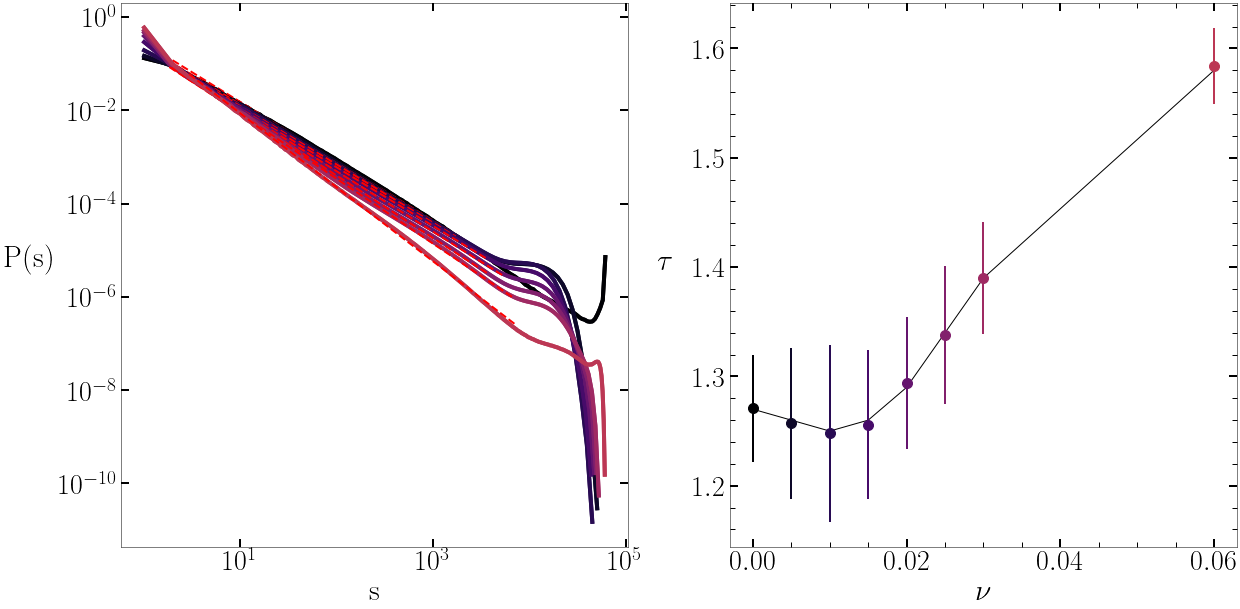

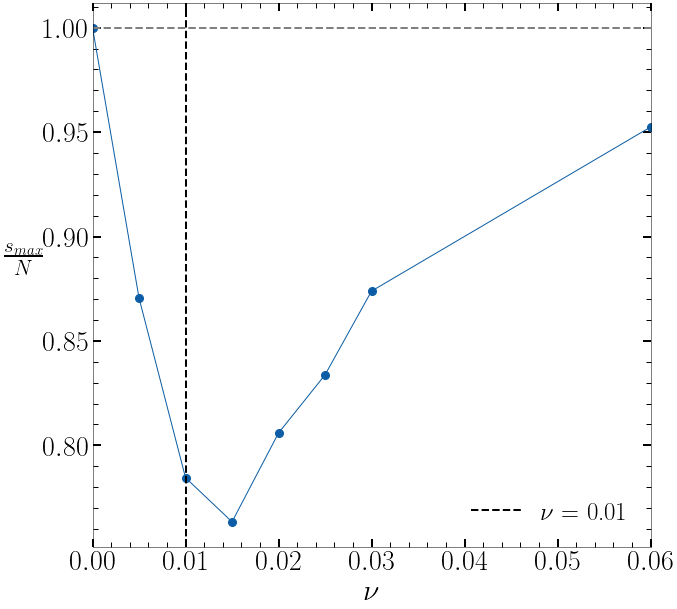

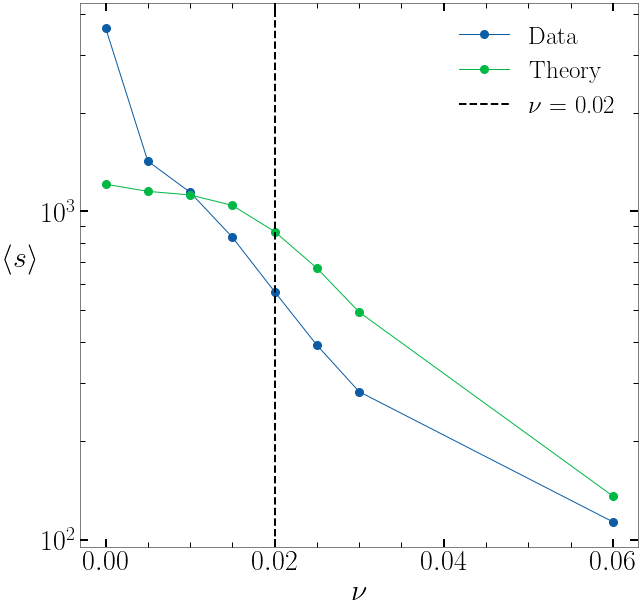

In [66]:
plt.figure(figsize=(20,10))
ax1 = plt.subplot(1,2,1)
ax2 = plt.subplot(1,2,2)

for j, (Tndist_j, Tndatafit_j, Tnstat_j, Tnzero_j, mean_j, nbins_j) in enumerate(results[:8]):
    
    mask = Tndist_j[:,1] != 1
    filt_Tndist_j = Tndist_j[mask]
    
    ax1.plot(filt_Tndist_j[:,0],filt_Tndist_j[:,1], color = colors[j],
            linewidth=4, mfc="none", label = f"{Tvar[j]}\nb = {-Tnstat_s[j]:.2f}") 
    
    if Tvar[j] == 0.0:
        result, xs, _ , perr = fit_powerlaw(filt_Tndist_j[:,0], filt_Tndist_j[:,1], stop_x = 5e3, start_x = start_x[j], switch = 1,  plot=True, f_scale=1.0,
                                    function_to_fit='power')
    else:
        result, xs, _ , perr = fit_powerlaw(filt_Tndist_j[:,0], filt_Tndist_j[:,1], n_cutoff = stop[j], start_x = start_x[j], plot=True, f_scale=1.0,
                                    function_to_fit='power')
    
    ##### Find the analytique mean of the powerlaw integral( x*ax**b)/integral(ax**b)##### 
    ax1.plot(Tndist_j[:,0][mask],Tndist_j[:,1][mask], color = colors[j],
            linewidth=4, markersize=6, mfc="none", label = f"{Tvar[j]}\nb = {-Tnstat_s[j]:.2f}") 
    ax1.plot(xs, powerlaw(xs, *result.x), 'r--', lw = 2, label='$a={} \pm {}$'.format(np.round(result.x[1], 2),
                                                                        np.round(perr[1], 2)))
    ax2.errorbar(Tvar[j], - np.round(result.x[1], 3), yerr = np.round(perr[1], 3), fmt = 'o', color = colors[j], lw =2, markersize = 10)
    
ax2.plot(Tvar[:8], -Ttau_s[:8], linestyle = '-', c = 'k', zorder=1)       
                
ax1.set_xscale("log")
ax1.set_yscale("log")
ax1.set_xlabel('s', fontsize=30)
ax1.set_ylabel('P(s) ', fontsize=30, rotation = 0, labelpad = 30)
ax1.tick_params(labelsize = 28,length = 8, width = 2)
ax1.tick_params(labelsize = 28,length = 5, width = 1, which = 'minor')
ax2.set_xlabel(r'$\nu$', fontsize=30)
ax2.set_ylabel(r'$\tau$', fontsize=30, rotation = 0, labelpad = 30)
ax2.tick_params(labelsize = 28,length = 8, width = 2)
ax2.tick_params(labelsize = 28,length = 5, width = 1, which = 'minor')
""" plt.legend(title_fontsize = 23, ncol = 2, loc='center left', bbox_to_anchor=(1, 0.5),fontsize = 25) """
plt.show()

#######S_max#######
plt.figure(figsize = (10,10))
plt.plot(Tvar, Tnonzero_s/(L1 * L2), markersize = 8, marker = 'o')
plt.axvline(Tvar[2], lw = 2, ls = '--', c = 'k', label = "{} = {}".format(macros['diss'], Tvar[2]))
plt.axhline(1, c = "grey", lw = 2, ls = '--')
plt.xlabel(r'$\nu$', fontsize=30)
plt.ylabel(r'$\frac{s_{max}}{N}$', fontsize = 30, rotation = 0,labelpad= 20)
plt.tick_params(labelsize = 28,length = 8, width = 2)
plt.tick_params(labelsize = 28,length = 5, width = 1, which = 'minor')
plt.xlim(0,Tvar[7])
plt.legend(fontsize = 25)
plt.show()

#######S_mean#######


plt.figure(figsize = (10,10))
ax2 = plt.subplot(1,1,1)

ax2.plot(Tvar[:8], Tmean_s[:8], markersize = 8, marker = 'o', label = "Data")
ax2.plot(Tvar[:8], Tana_mean[:8], markersize = 8, marker = 'o', label = "Theory")
ax2.axvline(Tvar[4], lw = 2, ls = '--', c = 'k', label = "{} = {}".format(macros['diss'], Tvar[4]))
ax2.set_xlabel(r'$\nu$', fontsize=30)
ax2.set_ylabel(r'$\langle s \rangle$', fontsize = 30, rotation = 0,labelpad= 20)
ax2.tick_params(labelsize = 28,length = 8, width = 2)
ax2.tick_params(labelsize = 28,length = 5, width = 1, which = 'minor')
ax2.set_yscale("log")

plt.legend(fontsize = 25)
plt.show()

##      Topplings

In [67]:
def process_top(folder, Lengthtab, nbins, nmin, nmax):
    data = np.loadtxt(f"{folder}/stat_histotop.txt", comments = "#")
    
    last_non_zero = np.nonzero(data)[0]
    
    mean = np.sum(data * np.arange(len(data)))/np.sum(data)
    
    ndatafit, ndistloglog, nstat = mainfct(data, Lengthtab, nbins, nmin, nmax)
    Tndist = 10 ** ndistloglog
    Tndatafit = 10 ** ndatafit
    Tnstat = nstat[0]
    
    return Tndist, Tndatafit, Tnstat, last_non_zero[-1], mean

def chunked_file_reader(filepath, chunksize=1e7, usecols=None):
        for chunk in pd.read_csv(filepath, compression='gzip', delim_whitespace=True, header=None, chunksize=chunksize, usecols=usecols, comment = "#"):
            yield chunk

In [68]:
lengthtab = L1 * L2 * 1000

# Tnmin = np.array([5,8, 8,8,7,7,7, 8,8,8,8, 8, 8, 8, 8])
# Tnmax = np.array([75,40,50,50,50,50,50, 80,80,80,80,80,80, 80])
# nbins = 100
# fnb = np.arange(1,14)
# folderpath = [f'/data1/DATA_Duplat/Brut/PDF/PD5n{nb}' for nb in fnb]
# Tvar = [read_parameters(folder)[2] for folder in folderpath]

results = Parallel(n_jobs=-1)(delayed(process_top)(folder, lengthtab, nbins, nmin, nmax)
                                  for (folder, nmin, nmax) in zip(folderpath, Tnmin, Tnmax))

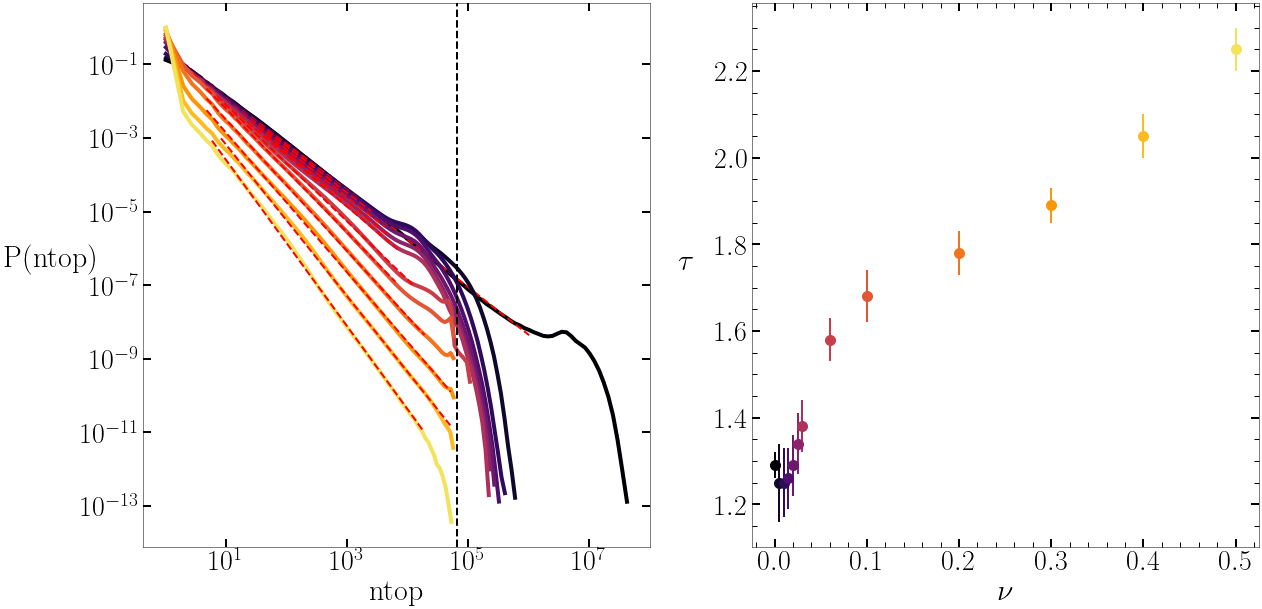

[51212938.   689601.   466086.   370704.   309831.   263949.   250579.
   121357.    64434.    64397.    64685.    63680.    59268.]


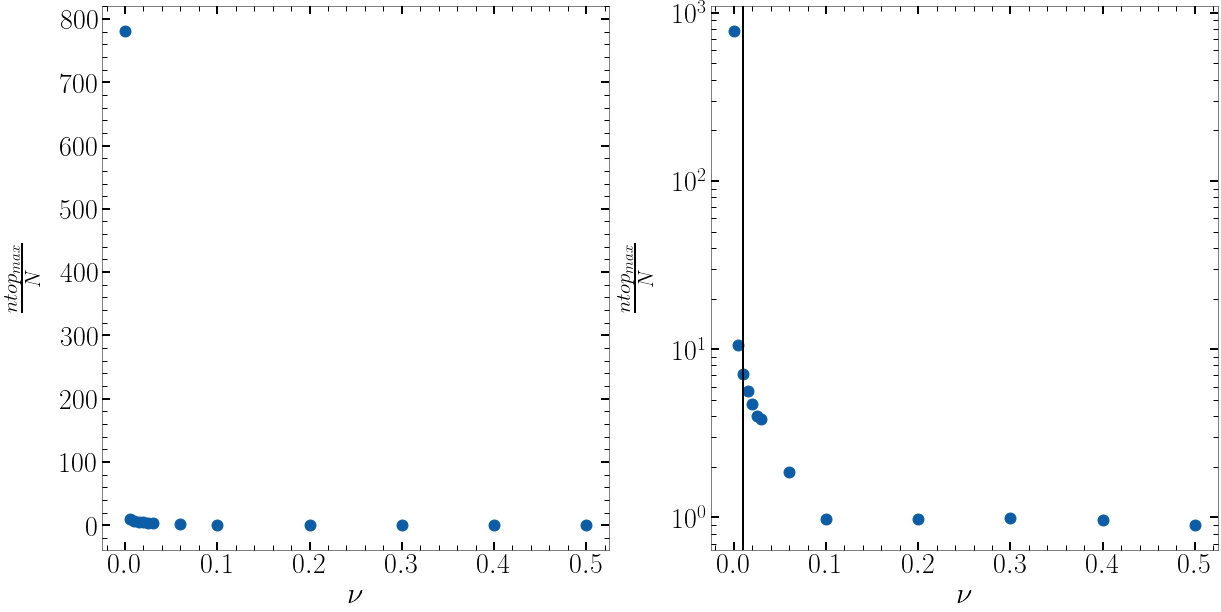

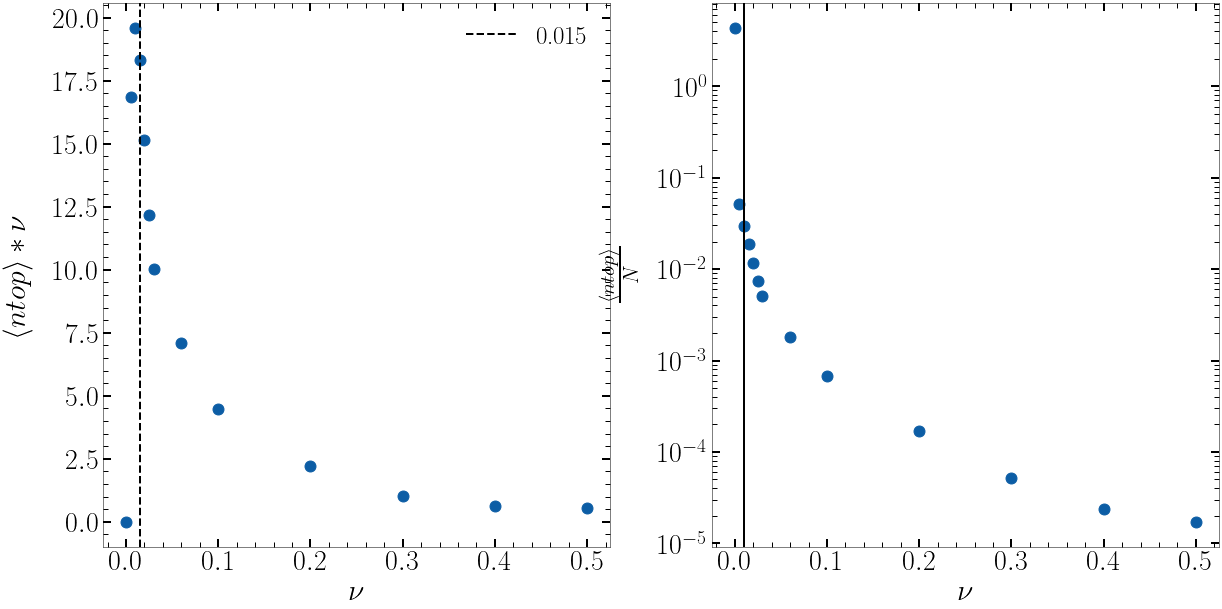

In [107]:
Tndist_t = np.zeros((len(folderpath),nbins, 2))
Tnstat_t = np.zeros(len(folderpath))
Tnonzero_t = np.zeros(len(folderpath))
Tmean_t = np.zeros(len(folderpath))
Tndatafit_t = np.zeros((len(folderpath),2,2))

NCURVES = len(folderpath)
cmap = plt.cm.get_cmap('inferno')
colors = [cmap(i / NCURVES) for i in range(NCURVES)]

plt.figure(figsize=(20,10))
ax1 = plt.subplot(1,2,1)
ax2 = plt.subplot(1,2,2)

stop = [6e-9, 3e-5, 2e-5, 1e-5, 4e-6, 2e-6, 1e-6, 1e-7, 1e-7, 4e-9, 1e-10, 1e-11, 1e-11, 1e-12]
start_x = [0,1,1,1,1,2,1,2,4,4,4,8,5,5]
Ttau_t = np.zeros(len(folderpath))
Tperr_t = np.zeros(len(folderpath))

for j, (Tndist_j, Tndatafit_j, Tnstat_j, Tnzero_j, mean_j) in enumerate(results[:]):
    Tndist_t[j] = Tndist_j
    Tndatafit_t[j] = Tndatafit_j
    Tnstat_t[j] = Tnstat_j    
    Tnonzero_t[j] = Tnzero_j
    Tmean_t[j] = mean_j
    
    mask = Tndist_j[:,1] != 1
    filt_Tndist_j = Tndist_j[mask]
    
    ax1.plot(filt_Tndist_j[:,0],filt_Tndist_j[:,1], color = colors[j],
            linewidth=4, markersize=6, mfc="none", label = f"{Tvar[j]}\nb = {-Tnstat_t[j]:.2f}") 
    
    
    result, xs, _ , perr = fit_powerlaw(filt_Tndist_j[:,0], filt_Tndist_j[:,1], n_cutoff = stop[j], start_x = start_x[j], plot=True, f_scale=1.0,
                                        function_to_fit='power')
    Ttau_t[j] = np.round(result.x[1], 2)
    Tperr_t[j] =  np.round(perr[1], 2)
    ax1.plot(xs, powerlaw(xs, *result.x), 'r--', lw = 2, label='$a={} \pm {}$'.format(np.round(result.x[1], 2),
                                                                         np.round(perr[1], 2)))
    ax2.errorbar(Tvar[j], - np.round(result.x[1], 2), yerr = np.round(perr[1], 2), fmt = 'o', color = colors[j], lw =2, markersize = 10)

# ax2.plot(Tvar, -Ttau_t, linestyle = '-', c = 'k', zorder=1)

ax1.axvline(L1 * L2, c = 'k', lw = 2, ls ='--')
ax1.set_xscale("log")
ax1.set_yscale("log")
ax1.set_xlabel('ntop', fontsize=30)
ax1.set_ylabel('P(ntop) ', fontsize=30, rotation = 0, labelpad = 30)
ax1.tick_params(labelsize = 28,length = 8, width = 2)
ax1.tick_params(labelsize = 28,length = 5, width = 1, which = 'minor')

ax2.set_xlabel(r'$\nu$', fontsize=30)
ax2.set_ylabel(r'$\tau$', fontsize=30, rotation = 0, labelpad = 30)
ax2.tick_params(labelsize = 28,length = 8, width = 2)
ax2.tick_params(labelsize = 28,length = 5, width = 1, which = 'minor')
""" plt.legend(title_fontsize = 23, ncol = 2, loc='center left', bbox_to_anchor=(1, 0.5),fontsize = 25) """
plt.show()

plt.figure(figsize = (20,10))
ax1 = plt.subplot(1,2,1)
ax2 = plt.subplot(1,2,2)

print(Tnonzero_t)

ax1.scatter(Tvar, Tnonzero_t/(L1 * L2), s = 120)
ax1.set_xlabel(r'$\nu$', fontsize=30)
ax1.set_ylabel(r'$\frac{ntop_{max}}{N}$', fontsize = 30, labelpad= 20)
ax1.tick_params(labelsize = 28,length = 8, width = 2)
ax1.tick_params(labelsize = 28,length = 5, width = 1, which = 'minor')

ax2.scatter(Tvar, Tnonzero_t/(L1 * L2), s = 120)
ax2.axvline(0.01, c = "k", lw = 2)
ax2.set_xlabel(r'$\nu$', fontsize=30)
ax2.set_ylabel(r'$\frac{ntop_{max}}{N}$', fontsize = 30, labelpad= 20)
ax2.set_yscale('log')
ax2.tick_params(labelsize = 28,length = 8, width = 2)
ax2.tick_params(labelsize = 28,length = 5, width = 1, which = 'minor')
plt.show()

plt.figure(figsize = (20,10))
ax1 = plt.subplot(1,2,1)
ax2 = plt.subplot(1,2,2)

ax1.scatter(Tvar, Tmean_t * Tvar, s = 120)
ax1.set_xlabel(r'$\nu$', fontsize=30)
ax1.axvline(Tvar[3], linestyle = '--', lw = 2, c = 'k', label = '{}'.format(Tvar[3]))
ax1.set_ylabel(r'$\langle ntop \rangle * \nu$', fontsize = 30,labelpad= 20)
ax1.tick_params(labelsize = 28,length = 8, width = 2)
ax1.tick_params(labelsize = 28,length = 5, width = 1, which = 'minor')
ax1.legend(fontsize = 25)

ax2.scatter(Tvar, Tmean_t/(L1 * L2), s = 120)
ax2.axvline(0.01, c = "k", lw = 2)
ax2.set_xlabel(r'$\nu$', fontsize=30) 
ax2.set_ylabel(r'$\frac{\langle ntop \rangle}{N}$', fontsize = 30,labelpad= 20)
ax2.tick_params(labelsize = 28,length = 8, width = 2)
ax2.tick_params(labelsize = 28,length = 5, width = 1, which = 'minor')
ax2.set_yscale("log")
plt.show()

##  Size exponants and Topplings exponants comparison

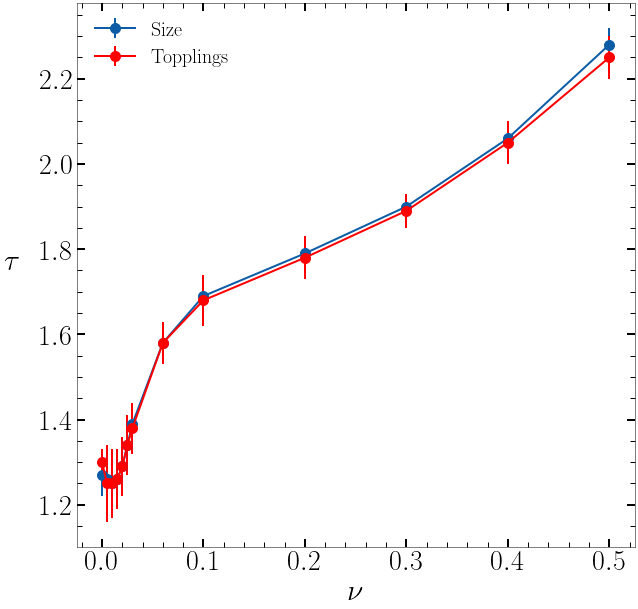

In [102]:
plt.figure(figsize = (10, 10))
plt.errorbar(Tvar, - Ttau_s, yerr = Tperr_s, fmt = '-o', lw = 2, markersize = 10, label = "Size", zorder = 3)
plt.errorbar(Tvar, -Ttau_t, yerr = Tperr_t, fmt = '-o', lw = 2, markersize = 10, c = 'r', label = "Topplings", zorder = 3)

plt.xlabel(r'$\nu$', fontsize=30)
plt.ylabel(r'$\tau$', fontsize=30, rotation = 0, labelpad = 30)
plt.tick_params(labelsize = 28,length = 8, width = 2)
plt.tick_params(labelsize = 28,length = 5, width = 1, which = 'minor')
plt.legend(fontsize = 20)
plt.show()

##      Intertime

In [2]:
def process_time(folder, nbins):
    histo = np.loadtxt(f"{folder}/stat_histoitime.txt", comments = "#")
    bins = np.logspace(np.log10(10**-12), np.log10(2), nbins)

    bin_centers = (bins[:-1] + bins[1:]) / 2
    mean = np.sum(histo * bin_centers) / np.sum(histo)
    
    norm_histo = histo/((np.diff(bins)) * histo.sum())
    norm_histo = norm_histo * mean
    
    norm_bin_centers = bin_centers/mean

    return norm_bin_centers, norm_histo
    

In [3]:
nbins = 1000

results = Parallel(n_jobs=-1)(delayed(process_time)(folder, nbins + 1)
                                  for folder in folderpath)


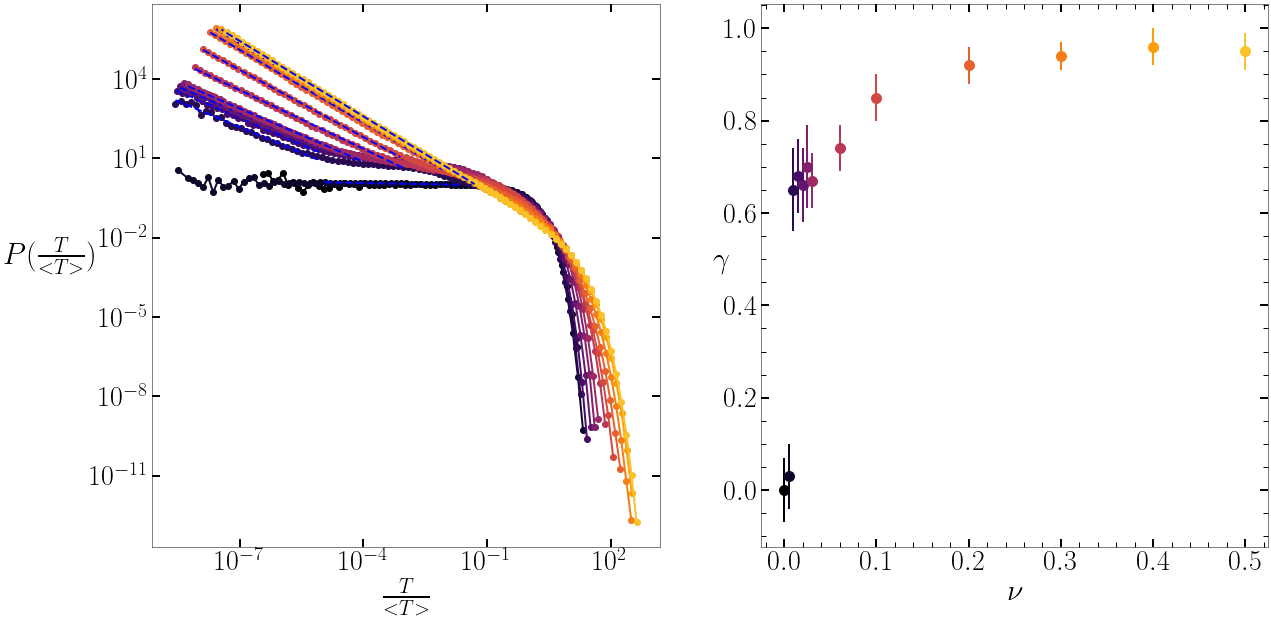

In [26]:
stop = [1e-1,1e-1,1e-5,1e-5,1e-5,
        1e-5,1e-4,1e-3,1e-3,1e-2,
        5e-2,5e-2,5e-2,5e-2]

start_x = [1e-5,1e-5,1e-10,1e-10,1e-10,
           1e-10,1e-10,1e-10,1e-10,1e-10,
           1e-10,1e-10,1e-10,1e-10]

NCURVES = len(folderpath) + 1
cmap = plt.cm.get_cmap('inferno')
colors = [cmap(i / NCURVES) for i in range(NCURVES)]

plt.figure(figsize = (20, 10))
ax1 = plt.subplot(1,2,1)
ax2 = plt.subplot(1,2,2)

red_nbins = 100

Tbins = np.zeros((len(folderpath), red_nbins + 1))
Thisto = np.zeros((len(folderpath), red_nbins))
Tb2 = np.zeros(len(folderpath))



Tgamma = np.zeros(len(folderpath))
Tperr = np.zeros(len(folderpath))

for j, (bin_center, histo) in enumerate(results[:]):
    
    bins_reduced, histo_reduced_norm = change_bins_log_histo(bin_center, histo, red_nbins)
    Tbins[j], Thisto[j] = change_bins_log_histo(bin_center, histo, red_nbins)
    
    mask = histo_reduced_norm!=0
    
    ax1.plot(bins_reduced[:-1][mask], histo_reduced_norm[mask], color = colors[j], marker = "o", lw = 2)
    
    result, xs, _ , perr = fit_powerlaw(bins_reduced[:-1][mask], histo_reduced_norm[mask], stop_x = stop[j], start_x = start_x[j], f_scale=1.0,
                                function_to_fit='power', switch = 1)
    ax1.plot(xs, powerlaw(xs, *result.x), 'b--', lw = 2, label='$a={} \pm {}$'.format(np.round(result.x[1], 2),
                                                                        np.round(perr[1], 2)))
    
    Tgamma[j] = np.round(result.x[1], 2)
    Tperr[j] =  np.round(perr[1], 2)
    
    ax2.errorbar(Tvar[j], - np.round(result.x[1], 2), yerr = np.round(perr[1], 2), fmt = 'o', color = colors[j], lw =2, markersize = 10)
    
# ax2.plot(Tvar, -Tgamma, linestyle = '-', c = 'k', zorder=1)


ax1.set_yscale('log')
ax1.set_xscale('log')
ax1.set_xlabel(r'$\frac{T}{<T>}$', fontsize = 30)
ax1.set_ylabel(r'$P(\frac{T}{<T>})$', fontsize = 30, rotation = 0,labelpad= 40)
ax1.tick_params(labelsize = 28,length = 8, width = 2)
ax1.tick_params(labelsize = 28,length = 5, width = 1, which = 'minor')

ax2.set_xlabel(r'$\nu$', fontsize = 30)
ax2.set_ylabel(r'$\gamma$', fontsize = 30, rotation = 0)
ax2.tick_params(labelsize = 28,length = 8, width = 2)
ax2.tick_params(labelsize = 28,length = 5, width = 1, which = 'minor')
plt.show()




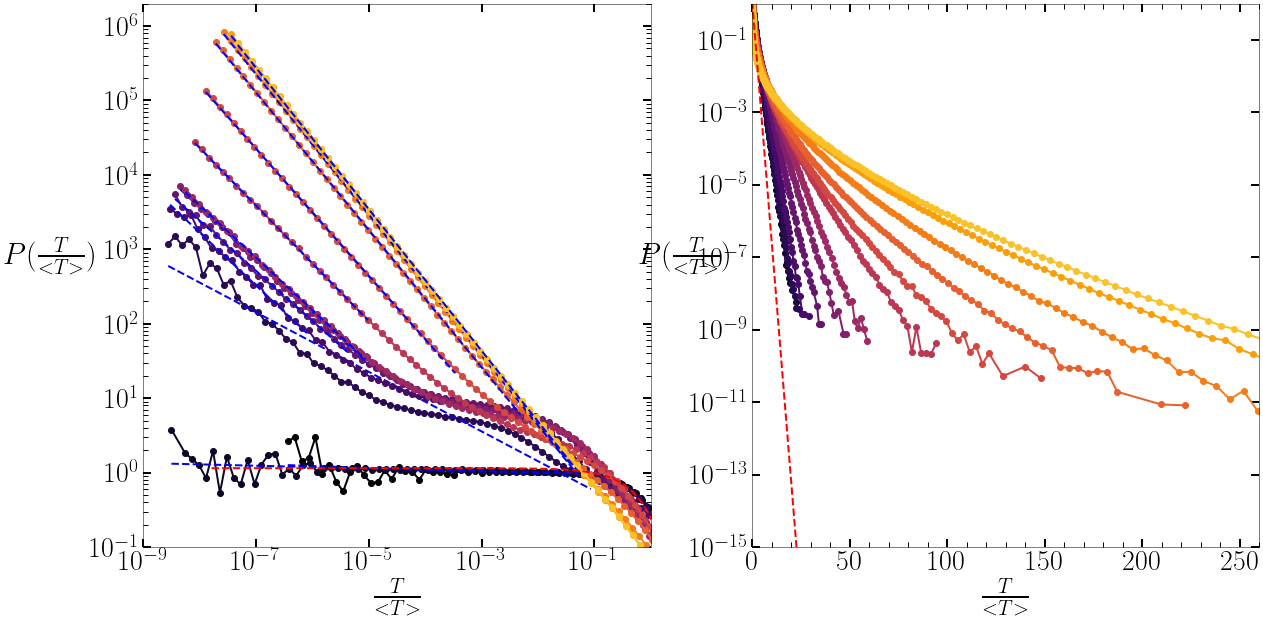

In [15]:

NCURVES = len(folderpath) + 1
cmap = plt.cm.get_cmap('inferno')
colors = [cmap(i / NCURVES) for i in range(NCURVES)]

plt.figure(figsize = (20, 10))
ax1 = plt.subplot(1,2,1)
ax2 = plt.subplot(1,2,2)

for j, (bin_center, histo) in enumerate(results):
    
    bins_reduced, histo_reduced_norm = change_bins_log_histo(bin_center, histo, 100)
    
    mask = histo_reduced_norm!=0
    mask3 = histo!=0
    
    ax1.plot(bins_reduced[:-1][mask], histo_reduced_norm[mask], color = colors[j], marker = "o", lw = 2)
    ax2.plot(bin_center[mask3], histo[mask3], color = colors[j], marker = "o", lw = 2) # To have more bins
    
    result, xs, _ , perr = fit_powerlaw(bins_reduced[:-1][mask], histo_reduced_norm[mask], stop_x = stop[j], start_x = start_x[j], f_scale=1.0,
                                function_to_fit='power', switch = 1)
            
    ax1.plot(xs, powerlaw(xs, *result.x), 'b--', lw = 2, label='$a={} \pm {}$'.format(np.round(result.x[1], 2),
                                                                        np.round(perr[1], 2)))

binsfit, histofit = results[0]
bins_reduced_fit, histo_reduced_norm_fit = change_bins_log_histo(binsfit, histofit, 100)

popt3, _ = curve_fit(expfct,bins_reduced_fit[:-1][histo_reduced_norm_fit!=0], histo_reduced_norm_fit[histo_reduced_norm_fit!=0])
a3,b3 = popt3
poisson = expfct(bins_reduced_fit[:-1], *popt3)
ax1.plot(bins_reduced_fit[:-1], poisson, linestyle = '--', color = 'r', lw = 2)
ax2.plot(bins_reduced_fit[:-1], poisson, linestyle = '--', color = 'r', lw = 2)


ax1.set_xlim(1e-9, 1)
ax1.set_ylim(1e-1, 2e6)
ax1.set_yscale('log')
ax1.set_xscale('log')
ax1.set_xlabel(r'$\frac{T}{<T>}$', fontsize = 30)
ax1.set_ylabel(r'$P(\frac{T}{<T>})$', fontsize = 30, rotation = 0,labelpad= 40)
ax1.tick_params(labelsize = 28,length = 8, width = 2)
ax1.tick_params(labelsize = 28,length = 5, width = 1, which = 'minor')

ax2.set_yscale('log')
ax2.set_ylim(1e-15, 1)
ax2.set_xlim(0,260)
ax2.set_xlabel(r'$\frac{T}{<T>}$', fontsize = 30)
ax2.set_ylabel(r'$P(\frac{T}{<T>})$', fontsize = 30, rotation = 0)
ax2.tick_params(labelsize = 28,length = 8, width = 2)
ax2.tick_params(labelsize = 28,length = 5, width = 1, which = 'minor')
plt.show()

### Sans rescale

In [16]:
# from tools import *

# nbins = 1000

# Tnmin = np.array([10,10, 10,10,10,10,10, 10,10,10,10, 10, 10, 10, 10])
# Tnmax = np.array([500,500,500,500,300,300,300, 300,350,400,500,500,550, 550])

# fnb = np.arange(1,15)
# folderpath = [f'/data1/DATA_Duplat/Brut/PDF/PD5n{nb}' for nb in fnb]
# Tvar = [read_parameters(folder)[2] for folder in folderpath]

In [17]:
def process_time(folder, nbins):
    histo = np.loadtxt(f"{folder}/stat_histoitime.txt", comments = "#")
    bins = np.logspace(np.log10(10**-12), np.log10(2), nbins)

    bin_centers = (bins[:-1] + bins[1:]) / 2
    return bins, bin_centers, histo

results = Parallel(n_jobs=-1)(delayed(process_time)(folder, nbins + 1)
                                  for folder in folderpath)



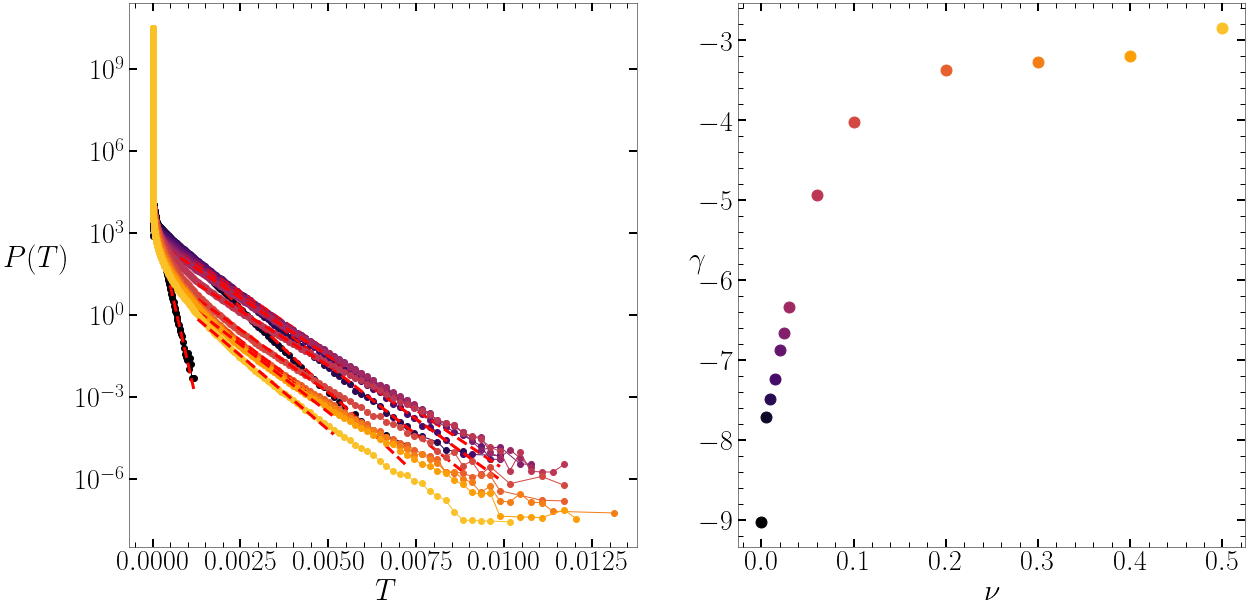

In [18]:
Tnmin2 = np.array([650,700,700,700,700,700,700,  740,740,740,740,740,740])
Tnmax2 = np.array([790,900,900,900,900,790,790,  790,790,790,790,790,790]) 


NCURVES = len(folderpath) + 1
cmap = plt.cm.get_cmap('inferno')
colors = [cmap(i / NCURVES) for i in range(NCURVES)]

plt.figure(figsize = (20, 10))
ax1 = plt.subplot(1,2,1)
ax2 = plt.subplot(1,2,2)

for j, (bins, bin_center, histo) in enumerate(results):

    histo /= ((np.diff(bins)) * histo.sum())
    ax1.plot(bin_center[histo!=0], histo[histo!=0], color = colors[j], marker = "o")
    
    try:
        
        mask = histo[Tnmin2[j]:Tnmax2[j]]!=0
        a, b = np.polyfit(bin_center[Tnmin2[j]:Tnmax2[j]][mask], np.log(histo[Tnmin2[j]:Tnmax2[j]][mask]), 1)
        y_fit = np.exp(b) * np.exp(a * bin_center[Tnmin2[j]:Tnmax2[j]][mask])
        
        ax1.plot(bin_center[Tnmin2[j]:Tnmax2[j]][histo[Tnmin2[j]:Tnmax2[j]]!=0], y_fit, linestyle = "--", color = 'r', linewidth = 3)
        ax2.scatter(Tvar[j], -b, color  = colors[j], s = 120)
        
    except ValueError:
        print("Error")
        continue

ax1.set_yscale('log')

ax1.set_xlabel(r'$T$', fontsize = 30)
ax1.set_ylabel(r'$P(T)$', fontsize = 30, rotation = 0,labelpad= 40)
ax1.tick_params(labelsize = 28,length = 8, width = 2)
ax1.tick_params(labelsize = 28,length = 5, width = 1, which = 'minor')

ax2.set_xlabel(r'$\nu$', fontsize = 30)
ax2.set_ylabel(r'$\gamma$', fontsize = 30, rotation = 0)
ax2.tick_params(labelsize = 28,length = 8, width = 2)
ax2.tick_params(labelsize = 28,length = 5, width = 1, which = 'minor')
plt.show()

### Size scaling

####     S = 2

In [7]:
fnb = np.arange(1,14)
folderpath = [f'/data1/DATA_Duplat/Brut/PDF/PD5n{nb}' for nb in fnb]
vartab = [read_parameters(folder)[2] for folder in folderpath]
nbins = 50
var = 'nu'

nmax = [25,30,30,30,30, 30,30,20,20,25,30,30,30] 

minsize = 2
Thisto2, Tbins2, Tb2, Tb22 = test_PDFtpsbava2(folderpath, vartab, nbins, nmax = nmax, size = minsize, limdata = 1e8)

EmptyDataError: No columns to parse from file

####    S = 10

In [ ]:
fnb = np.arange(1,14)
folderpath = [f'/data1/DATA_Duplat/Brut/PDF/PD5n{nb}' for nb in fnb]
vartab = [read_parameters(folder)[2] for folder in folderpath]
nbins = 50
var = 'nu'

nmax = [25,30,30,30,30, 30,30,20,20,30,30,30,30] 

minsize = 10
Thisto10, Tbins10, Tb10, Tb210 = test_PDFtpsbava2(folderpath, vartab, nbins, nmax = nmax, size = minsize, limdata = 1e8)

####    S = 100

In [ ]:
fnb = np.arange(1,14)
folderpath = [f'/data1/DATA_Duplat/Brut/PDF/PD5n{nb}' for nb in fnb]
vartab = [read_parameters(folder)[2] for folder in folderpath]
nbins = 50
var = 'nu'

nmax = [25,30,30,30,30, 30,30,20,20,30,30,30,30] 

minsize = 100
Thisto100, Tbins100, Tb100, Tb2100 = test_PDFtpsbava2(folderpath, vartab, nbins, nmax = nmax, size = minsize, limdata = 1e8)

####    S = 1000

In [ ]:
fnb = np.arange(1,14)
folderpath = [f'/data1/DATA_Duplat/Brut/PDF/PD5n{nb}' for nb in fnb]
vartab = [read_parameters(folder)[2] for folder in folderpath]
nbins = 50
var = 'nu'

nmax = [25,30,30,30,30, 30,30,20,20,30,30,30,30] 

minsize = 1000
Thisto1000, Tbins1000, Tb1000, Tb21000 = test_PDFtpsbava2(folderpath, vartab, nbins, nmax = nmax, size = minsize, limdata = 1e8)

####    S = 6500

In [ ]:
fnb = np.arange(1,14)
folderpath = [f'/data1/DATA_Duplat/Brut/PDF/PD5n{nb}' for nb in fnb]
vartab = [read_parameters(folder)[2] for folder in folderpath]
nbins = 50
var = 'nu'

nmax = [25,30,30,30,30, 30,30,20,20,30,30,30,30] 

minsize = 65000
Thisto10000, Tbins10000, Tb10000, Tb210000 = test_PDFtpsbava2(folderpath, vartab, nbins, nmax = nmax, size = minsize, limdata = 1e8)

####     Recap

In [ ]:
NCURVES = 4
cmap = plt.cm.get_cmap('inferno')
colors = [cmap(i / NCURVES) for i in range(NCURVES)]

fnb = np.arange(1,15)
folderpath = [f'/data1/DATA_Duplat/Brut/PDF/PD5n{nb}' for nb in fnb]
vartab = [read_parameters(folder)[2] for folder in folderpath]


plt.figure(figsize = (20,10))
ax1 = plt.subplot(1,2,1)
ax2 = plt.subplot(1,2,2)

for i in range(len(folderpath)):
    
    mask = Thisto[i] != 0
    ax1.plot(Tbins[i, :-1][mask], Thisto[i][mask], color = colors[0],  marker = 'o', linewidth = 3)
    
    if i < 13:
        mask2 = Thisto2[i, :] != 0
        ax1.plot(Tbins2[i, :][mask2], Thisto2[i][mask2], color = colors[1],  marker = 'o', linewidth = 3)
        
        mask10 = Thisto10[i, :] != 0
        ax1.plot(Tbins10[i, :][mask10], Thisto10[i][mask10], color = colors[2], marker = 'o', linewidth = 3)
        
        mask100 = Thisto100[i, :] != 0
        ax1.plot(Tbins100[i, :][mask100], Thisto100[i][mask100], color = colors[3], marker = 'o', linewidth = 3)
        
        # mask1000 = Thisto1000[i, :] != 0
        # ax1.plot(Tbins1000[i, :][mask1000], Thisto1000[i][mask1000], color = colors[4], marker = 'o', linewidth = 3, label = r"$s \geq  1000$")
    
        # mask10000 = Thisto2[i, :] != 0
        # ax1.plot(Tbins10000[i, :][mask10000], Thisto10000[i][mask10000], label = 's = 10000', marker = 'o', linewidth = 3)
    
ax1.set_yscale('log')
ax1.set_xscale('log')
ax1.set_xlabel(r'$\frac{T_{E}}{<T_{E}>}$', fontsize = 30)
ax1.set_ylabel(r'$P(\frac{T_{E}}{<T_{E}>})$', fontsize = 30, rotation = 0,labelpad= 40)
ax1.tick_params(labelsize = 28,length = 8, width = 2)
ax1.tick_params(labelsize = 28,length = 5, width = 1, which = 'minor')
ax1.set_xlim(1e-10, 1e2)
ax1.set_ylim(1e-9, 1e5)


print(Tb2)
ax2.plot(vartab, -Tb2, markersize = 10, marker = 'o', color = colors[0], label = r"$s \geq  1$")
ax2.plot(vartab[:-1], -Tb22, markersize = 10, marker = 'o', color = colors[1], label = r"$s \geq  2$")
ax2.plot(vartab[:-1], -Tb210, markersize = 10, marker = 'o', color = colors[2], label = r"$s \geq  10$")
ax2.plot(vartab[:-1], -Tb2100, markersize = 10, marker = 'o', color = colors[3], label = r"$s \geq  100$")
# ax2.scatter(vartab[:-1], -Tb21000, s = 120, color = colors[4], label = r"$s \geq  1000$")
ax2.set_xlabel(r'$\nu$', fontsize = 30)
ax2.set_ylabel(r'$\gamma$', fontsize = 30, rotation = 0)
ax2.tick_params(labelsize = 28,length = 8, width = 2)
ax2.tick_params(labelsize = 28,length = 5, width = 1, which = 'minor')
plt.legend(loc='center left', bbox_to_anchor=(1, 0.5),fontsize = 25)
plt.show()

### For S >= 2 (with histogram)

In [4]:
def process_time2(folder, nbins):
    histo = np.loadtxt(f"{folder}/stat_histoitime2.txt", comments = "#")
    bins = np.logspace(np.log10(10**-12), np.log10(2), nbins)

    bin_centers = (bins[:-1] + bins[1:]) / 2
    mean = np.sum(histo * bin_centers) / np.sum(histo)
    
    norm_histo = histo/((np.diff(bins)) * histo.sum())
    norm_histo = norm_histo * mean
    
    norm_bin_centers = bin_centers/mean

    return norm_bin_centers, norm_histo
    

In [5]:
nbins = 1000

results = Parallel(n_jobs=-1)(delayed(process_time2)(folder, nbins + 1)
                                  for folder in folderpath)

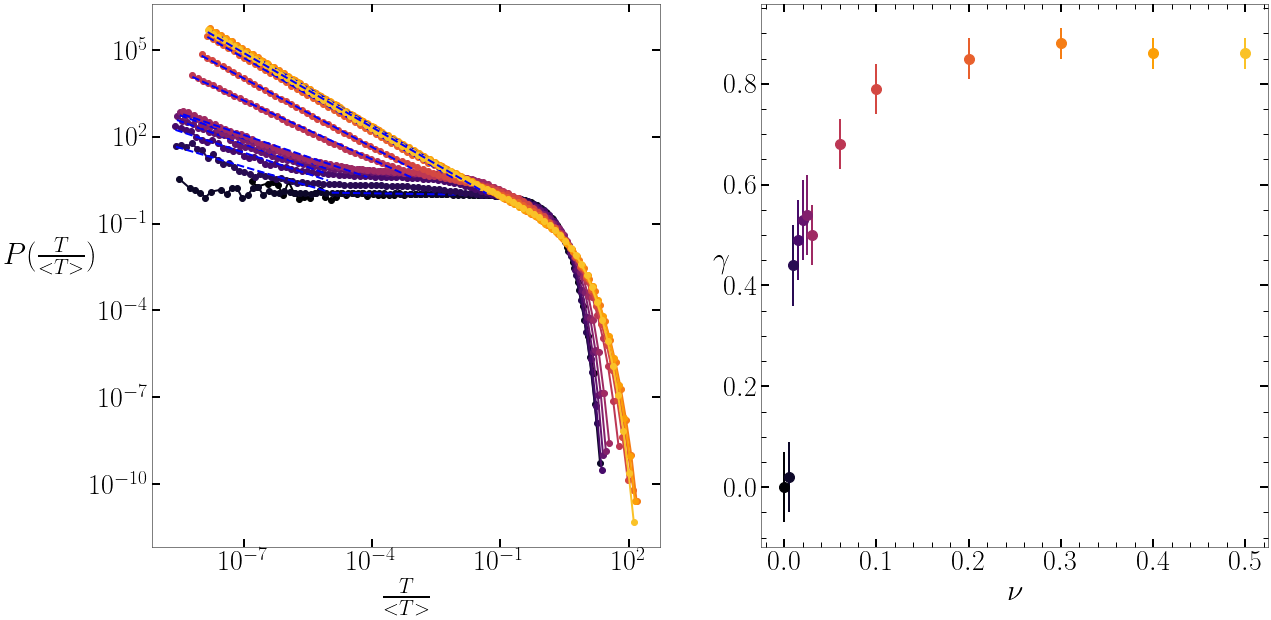

In [6]:
stop = [1e-1,1e-1,1e-5,1e-5,1e-5,
        1e-5,1e-4,1e-3,1e-3,1e-2,
        5e-2,5e-2,5e-2,5e-2]

start_x = [1e-5,1e-5,1e-10,1e-10,1e-10,
           1e-10,1e-10,1e-10,1e-10,1e-10,
           1e-10,1e-10,1e-10,1e-10]

NCURVES = len(folderpath) + 1
cmap = plt.cm.get_cmap('inferno')
colors = [cmap(i / NCURVES) for i in range(NCURVES)]

plt.figure(figsize = (20, 10))
ax1 = plt.subplot(1,2,1)
ax2 = plt.subplot(1,2,2)

red_nbins = 100

Tbins = np.zeros((len(folderpath), red_nbins + 1))
Thisto = np.zeros((len(folderpath), red_nbins))
Tb2 = np.zeros(len(folderpath))



Tgamma = np.zeros(len(folderpath))
Tperr = np.zeros(len(folderpath))

for j, (bin_center, histo) in enumerate(results[:]):
    
    bins_reduced, histo_reduced_norm = change_bins_log_histo(bin_center, histo, red_nbins)
    Tbins[j], Thisto[j] = change_bins_log_histo(bin_center, histo, red_nbins)
    
    mask = histo_reduced_norm!=0
    
    ax1.plot(bins_reduced[:-1][mask], histo_reduced_norm[mask], color = colors[j], marker = "o", lw = 2)
    
    result, xs, _ , perr = fit_powerlaw(bins_reduced[:-1][mask], histo_reduced_norm[mask], stop_x = stop[j], start_x = start_x[j], f_scale=1.0,
                                function_to_fit='power', switch = 1)
    ax1.plot(xs, powerlaw(xs, *result.x), 'b--', lw = 2, label='$a={} \pm {}$'.format(np.round(result.x[1], 2),
                                                                        np.round(perr[1], 2)))
    
    Tgamma[j] = np.round(result.x[1], 2)
    Tperr[j] =  np.round(perr[1], 2)
    
    ax2.errorbar(Tvar[j], - np.round(result.x[1], 2), yerr = np.round(perr[1], 2), fmt = 'o', color = colors[j], lw =2, markersize = 10)
    
# ax2.plot(Tvar, -Tgamma, linestyle = '-', c = 'k', zorder=1)


ax1.set_yscale('log')
ax1.set_xscale('log')
ax1.set_xlabel(r'$\frac{T}{<T>}$', fontsize = 30)
ax1.set_ylabel(r'$P(\frac{T}{<T>})$', fontsize = 30, rotation = 0,labelpad= 40)
ax1.tick_params(labelsize = 28,length = 8, width = 2)
ax1.tick_params(labelsize = 28,length = 5, width = 1, which = 'minor')

ax2.set_xlabel(r'$\nu$', fontsize = 30)
ax2.set_ylabel(r'$\gamma$', fontsize = 30, rotation = 0)
ax2.tick_params(labelsize = 28,length = 8, width = 2)
ax2.tick_params(labelsize = 28,length = 5, width = 1, which = 'minor')
plt.show()




## Average intertime

### S = 1 (histogram is used)

In [20]:
def process_meantime(folder, nbins):
    histo = np.loadtxt(f"{folder}/stat_histoitime.txt", comments = "#")
    bins = np.logspace(np.log10(10**-12), np.log10(2), nbins)

    bin_centers = (bins[:-1] + bins[1:]) / 2
    mean = np.sum(histo * bin_centers) / np.sum(histo)
    
    return mean

In [21]:
nbins = 1000

# fnb = np.arange(1,15)
# folderpath = [f'/data1/DATA_Duplat/Brut/PDF/PD5n{nb}' for nb in fnb]
# Tvar = [read_parameters(folder)[2] for folder in folderpath]


results = Parallel(n_jobs=-1)(delayed(process_meantime)(folder, nbins + 1)
                                  for folder in folderpath)

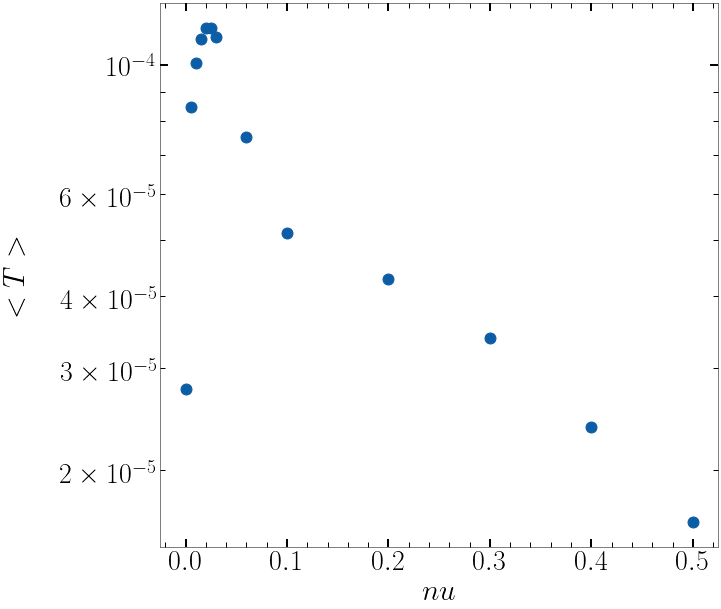

In [22]:
mean = results

semilogfig_scatter(Tvar, mean, r"$nu$", r"$<T>$")

### S = 2 (Sample is used)

In [ ]:
def process_meantime_th(folder, minsize, limdata = 1e9):

    histo = np.zeros(nbins)
    bins = np.logspace(np.log10(10**-12), np.log10(10**2), nbins + 1)
    csize = 1e7
    nbdata = 0
    
    lasttime = 0
    last_filtered_time = 0
    norm = 0
    suminter  = 0
    
    for chunk in chunked_file_reader(f'{folder}/Avalanche_outputB.gz', chunksize=csize, usecols = [1,3]):
        
        time = np.array(np.cumsum(chunk.iloc[:, 1])) + lasttime #rebuild the time scale starting from zero using dz
        lasttime = time[-1]  #Save the time for the next chunk
        # filterd_chunk = chunk.iloc[:, 1][chunk.iloc[:, 0] >= minsize]
        
        filtered_time = time[chunk.iloc[:, 0] >= minsize] #Keep only the avalanches with a size above a threshold
        filtered_time = np.insert(filtered_time, 0, last_filtered_time) #add to the array the time of the last avalanches from the previous chunk
        last_filtered_time = filtered_time[-1]  #Keep the time of the last avalanches for the next chunk
        
        if(len(filtered_time) > 0):
            time_inter = np.diff(filtered_time)
            
            suminter += np.sum(time_inter)
            norm += len(time_inter)
            
        nbdata+=len(time)
        
        if nbdata >= limdata: break
        
        
    # histo = histo/nbdata
    mean = suminter/norm
        
    return mean
        

In [ ]:
# fnb = np.arange(1,14)
# folderpath = [f'/data1/DATA_Duplat/Brut/PDF/PD5n{nb}' for nb in fnb]
# Tvar = [read_parameters(folder)[2] for folder in folderpath]

print(Tvar)
limdata = 1e8
minsize = 2
results = Parallel(n_jobs=-1)(delayed(process_meantime_th)(folder, minsize, limdata)
                                  for folder in folderpath)

[0.0, 0.005, 0.01, 0.015, 0.02, 0.025, 0.03, 0.06, 0.1, 0.2, 0.3, 0.4, 0.5]


EmptyDataError: No columns to parse from file

In [ ]:
mean2 = results

semilogfig_scatter(Tvar, mean2, "nu", r"$<T>$")

### S = 10

In [ ]:
# fnb = np.arange(1,14)
# folderpath = [f'/data1/DATA_Duplat/Brut/PDF/PD5n{nb}' for nb in fnb]
# Tvar = [read_parameters(folder)[2] for folder in folderpath]

limdata = 1e8
minsize = 10
results = Parallel(n_jobs=-1)(delayed(process_meantime_th)(folder, minsize, limdata)
                                  for folder in folderpath)

In [ ]:
mean10 = results

semilogfig_scatter(Tvar, mean10, "nu", r"$<T>$")

### S = 100

In [ ]:
# fnb = np.arange(1,14)
# folderpath = [f'/data1/DATA_Duplat/Brut/PDF/PD5n{nb}' for nb in fnb]
# Tvar = [read_parameters(folder)[2] for folder in folderpath]

limdata = 1e8
minsize = 100
results = Parallel(n_jobs=-1)(delayed(process_meantime_th)(folder, minsize, limdata)
                                  for folder in folderpath)

In [ ]:
mean100 = results

semilogfig_scatter(Tvar, mean100, "nu", r"$<T>$")

### S = 1000

In [ ]:
# fnb = np.arange(1,14)
# folderpath = [f'/data1/DATA_Duplat/Brut/PDF/PD5n{nb}' for nb in fnb]
# Tvar = [read_parameters(folder)[2] for folder in folderpath]

limdata = 1e8
minsize = 1000
results = Parallel(n_jobs=-1)(delayed(process_meantime_th)(folder, minsize, limdata)
                                  for folder in folderpath)

In [ ]:
mean1000 = results

semilogfig_scatter(Tvar, mean1000, "nu", r"$<T>$")

### S = 10000

In [ ]:
# fnb = np.arange(1,14)
# folderpath = [f'/data1/DATA_Duplat/Brut/PDF/PD5n{nb}' for nb in fnb]
# Tvar = [read_parameters(folder)[2] for folder in folderpath]

limdata = 1e8
minsize = 10000
results = Parallel(n_jobs=-1)(delayed(process_meantime_th)(folder, minsize, limdata)
                                  for folder in folderpath)

In [ ]:
mean10000 = results

semilogfig_scatter(Tvar, mean10000, "nu", r"$<T>$")

### Récap

In [ ]:
NCURVES = 6
cmap = plt.cm.get_cmap('inferno') 
colors = [cmap(i / NCURVES) for i in range(NCURVES)]


plt.figure(figsize = (10,10))
plt.plot(Tvar, mean[:-1], markersize = 10, marker = 'o', color = colors[0], label = r"$s \geq  1$")
plt.plot(Tvar, mean2, markersize = 10, marker = 'o', color = colors[1], label = r"$s \geq  2$")
plt.plot(Tvar, mean10, markersize = 10, marker = 'o', color = colors[2], label = r"$s \geq  10$")
plt.plot(Tvar, mean100, markersize = 10, marker = 'o', color = colors[3], label = r"$s \geq  100$")
plt.plot(Tvar, mean1000, markersize = 10, marker = 'o', color = colors[4], label = r"$s \geq  1000$")
plt.plot(Tvar, mean10000, markersize = 10, marker = 'o', color = colors[5], label = r"$s \geq  10000$")
plt.yscale("log")
plt.xlabel(r"$\nu$", fontsize=30)
plt.ylabel(r"$\langle T \rangle$", fontsize=30, labelpad = 30)
plt.tick_params(labelsize = 28,length = 8, width = 2)
plt.tick_params(labelsize = 28,length = 5, width = 1, which = 'minor')
# plt.legend(fontsize = 20)
plt.legend(loc='center left', bbox_to_anchor=(1, 0.5),fontsize = 25)
plt.show()

## Omori's law

In [ ]:
def histoOmori(folder, nbins, bins, minsize, limdata):
    histo = np.zeros(nbins)

    csize = 1e7
    nbdata = 0
    
    begin = 0
    time = 0
    col = [1,3]
    
    maxtime = 1.5 * 10**-5
    
    def chunked_file_reader(filepath, chunksize=1e7, usecols=None):
        for chunk in pd.read_csv(filepath, compression='gzip', delim_whitespace=True, header=None, chunksize=chunksize, usecols=usecols):
            yield chunk
    
    for chunk in chunked_file_reader(f'{folder}/Avalanche_outputB.gz', chunksize=1e7, usecols=col):
        intertime = np.zeros(int(csize))
        for i, (s, dz) in enumerate(zip(chunk.iloc[:, 0], chunk.iloc[:, 1])):
            
            if begin == 0 and s < minsize: continue
            
            time += dz  
            if s >= minsize: 
                if begin == 0: begin = 1
                time = 0
            
            if time >= maxtime: continue
            intertime[i] = time
        
        intertime_filtered = intertime[intertime[:] != 0]
        histo += np.histogram(intertime_filtered, bins = bins)[0]
        nbdata+=len(chunk)
        
        if nbdata == limdata: break
        
        
    return histo

In [ ]:
# fnb = np.arange(1,14)
# folderpath = [f'/data1/DATA_Duplat/Brut/PDF/PD5n{nb}' for nb in fnb]
minsize = 10
nbins = 50
limdata = 1e8
bins = np.logspace(np.log10(10**-9), np.log10(1), nbins + 1)

results = Parallel(n_jobs=5)(delayed(histoOmori)(folder, nbins, bins, minsize, limdata)
                                  for folder in folderpath)


In [ ]:
bins = np.logspace(np.log10(10**-9), np.log10(1), nbins + 1)
norm_histo = np.zeros((len(folderpath), nbins))
norm_histo_rescaled = np.zeros((len(folderpath), nbins))

histo = np.zeros((len(folderpath), nbins))

for i, result in enumerate(results):
    histo[i] = result

bin_centers = (bins[:-1] + bins[1:]) / 2
norm_bin_centers_rescaled = np.zeros((len(histo), len(bin_centers)))

    
for i in range(len(histo)):
    mean = np.sum(histo[i] * bin_centers) / np.sum(histo[i])
    norm_histo[i] = histo[i]/((np.diff(bins)) * np.sum(histo[i]))
    norm_histo_rescaled[i] = histo[i]/((np.diff(bins)) * np.sum(histo[i]))
    norm_bin_centers_rescaled[i] = bin_centers



In [ ]:
NCURVES = len(folderpath) 
cmap = plt.cm.get_cmap('inferno')
colors = [cmap(i / NCURVES) for i in range(NCURVES)]


vartab = [read_parameters(folder)[2] for folder in folderpath]
Txmin_pl = [10,14,10,10,0,12,10,2,0,0,0,0,4,0,0]
Txmax_pl = [45,48,48,48,48,48,48,25,30,40,48,40,44,48,48]

n = 12

Tb2 = np.zeros(len(folderpath))
Ta1 = np.zeros(len(folderpath))

plt.figure(figsize = (20,10))
ax1 = plt.subplot(1,2,1)
ax2 = plt.subplot(1,2,2)

# for i in range(len(folderpath)):
for i, (bins, histo, xmin_pl, xmax_pl) in enumerate(zip(norm_bin_centers_rescaled, norm_histo_rescaled, Txmin_pl,Txmax_pl)):
    mask = histo!= 0
    
    scal = len(bins[mask])/len(bins)
    

    ax1.plot(bins[mask], histo[mask], label = vartab[i], color = colors[i], lw = 3, marker = 'o')
    try: 
        
        s_xmin_pl = int(xmin_pl * scal)
        s_xmax_pl = int(xmax_pl * scal)
        
        
        mask2 = histo[s_xmin_pl:s_xmax_pl] !=0
        popt2, _ = curve_fit(powerlaw2, np.log(bins[s_xmin_pl:s_xmax_pl][mask2]), np.log(histo[s_xmin_pl:s_xmax_pl][mask2]))
        a2,b2 = popt2
        yfit2 = np.exp(powerlaw2(np.log(bins[s_xmin_pl:s_xmax_pl][mask2]), *popt2))
        Tb2[i] = b2


        ax1.plot(bins[s_xmin_pl:s_xmax_pl][mask2], yfit2, linestyle = "--", color = 'b', linewidth = 3)
    except ValueError:
        print("Error")
        continue 


ax1.set_xscale("log")
ax1.set_yscale("log")
ax1.set_xlabel(r'$t$', fontsize=30)
ax1.set_ylabel(r'$P(t)$', fontsize=30, rotation = 0, labelpad = 30)
ax1.tick_params(labelsize = 28,length = 8, width = 2)
ax1.tick_params(labelsize = 28,length = 5, width = 1, which = 'minor')
ax1.legend(title = rf'$\nu$', fontsize = 23, title_fontsize = 23)

ax2.scatter(vartab, -Tb2, color  = 'b', s = 120, label = r'$\gamma$')
ax2.axvline(x = 0.03, color = 'k', ls = '--', lw = 2)
ax2.set_xlabel(r'$\nu$', fontsize = 30)
ax2.set_ylabel(r'$\gamma$', fontsize = 30, rotation = 0)
ax2.tick_params(labelsize = 28,length = 8, width = 2)
ax2.tick_params(labelsize = 28,length = 5, width = 1, which = 'minor')


plt.show()


## Propagation Time

In [23]:
def process_tprop(folder, Lengthtab, nbins, nmin, nmax):
    data = np.loadtxt(f"{folder}/stat_histotprop.txt", comments = "#")
    
    last_non_zero = np.nonzero(data)[0]
    
    mean = np.sum(data * np.arange(len(data)))/np.sum(data)
    
    ndatafit, ndistloglog, nstat = mainfct(data, Lengthtab, nbins, nmin, nmax)
    Tndist = 10 ** ndistloglog
    Tndatafit = 10 ** ndatafit
    Tnstat = nstat[0]
    
    return Tndist, Tndatafit, Tnstat, last_non_zero[-1], mean
    

In [24]:
Tnmin = np.array([1,1, 1,1,1,1,1, 1,3,3,3,5, 5, 5])
Tnmax = np.array([60,40,40,40,40,40,40, 60,60,60,60,60,60, 60])
nbins = 100
lengthtab = L1 * L2 * 1000

# fnb = np.arange(1,14)
# folderpath = [f'/data1/DATA_Duplat/Brut/PDF/PD5n{nb}' for nb in fnb]
# Tvar2 = [read_parameters(folder)[2] for folder in folderpath]

results = Parallel(n_jobs=-1)(delayed(process_tprop)(folder, lengthtab, nbins, nmin, nmax)
                                  for (folder, nmin, nmax) in zip(folderpath, Tnmin, Tnmax))

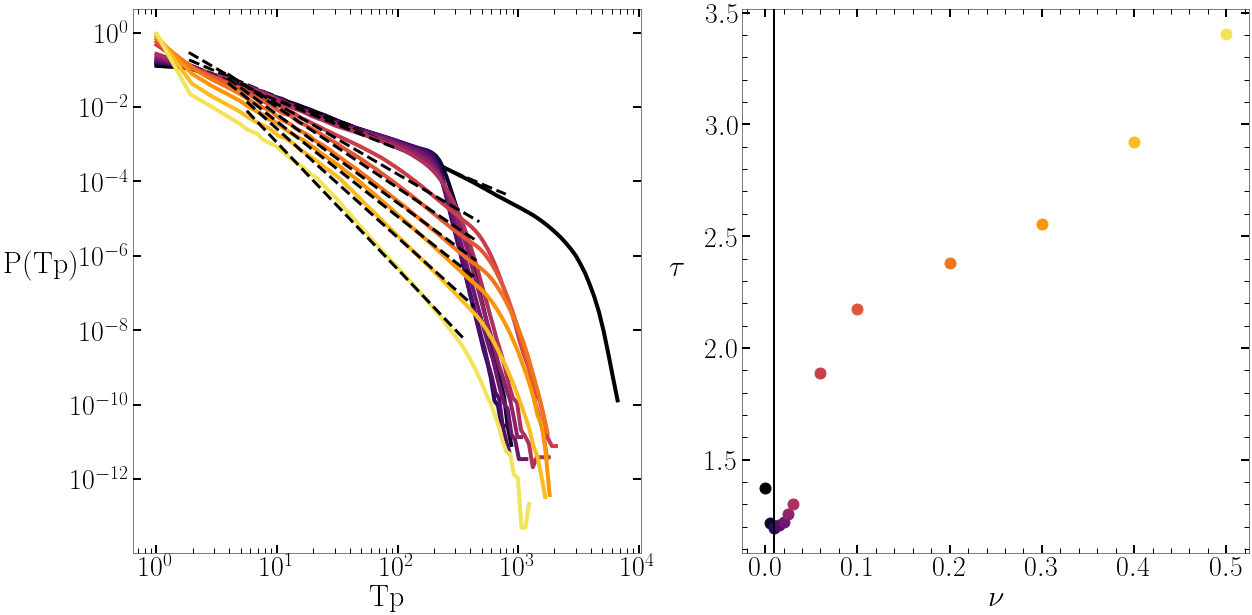

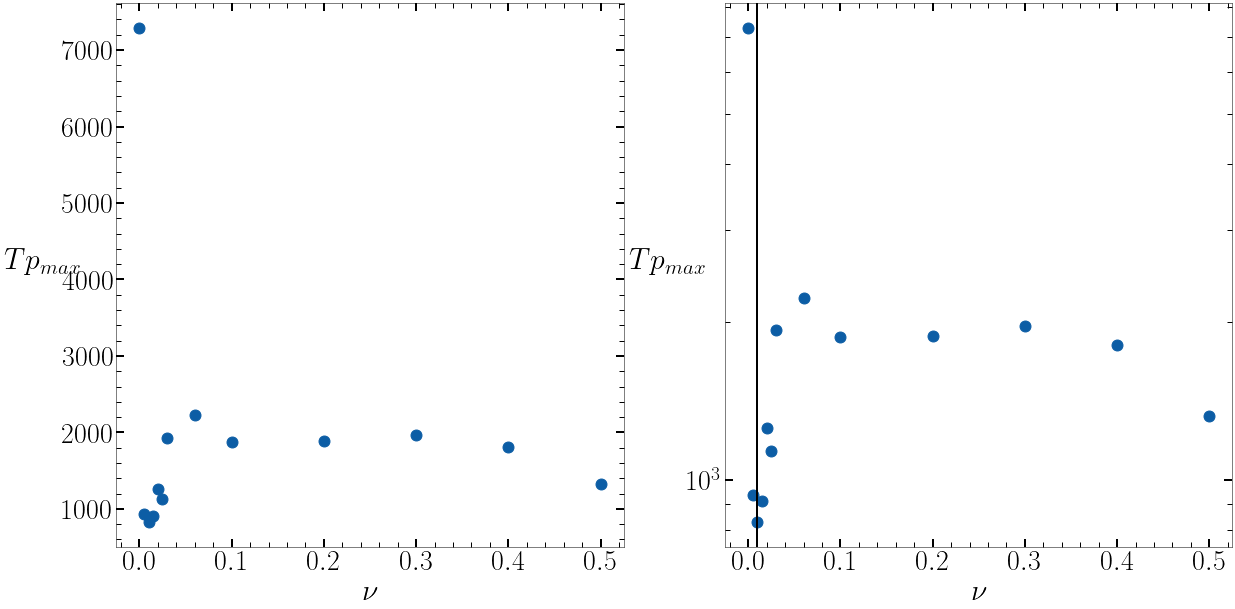

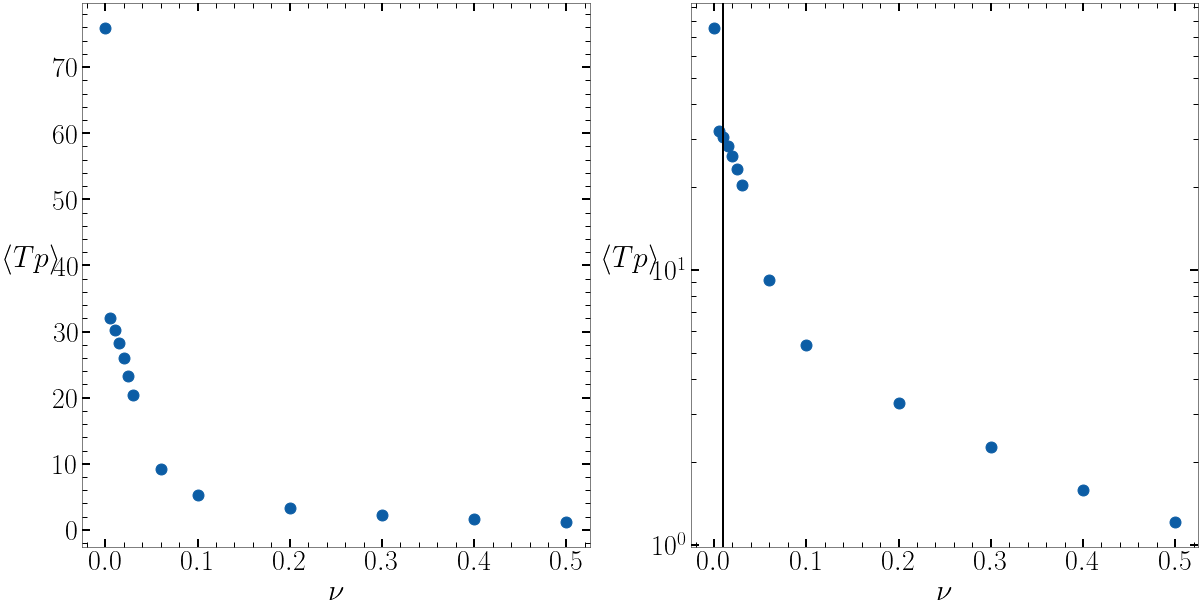

In [25]:
Tndist = np.zeros((len(folderpath),nbins, 2))
Tnstat = np.zeros(len(folderpath))
Tnonzero = np.zeros(len(folderpath))
Tmean = np.zeros(len(folderpath))
Tndatafit = np.zeros((len(folderpath),2,2))

NCURVES = len(folderpath)
cmap = plt.cm.get_cmap('inferno')
colors = [cmap(i / NCURVES) for i in range(NCURVES)]

plt.figure(figsize=(20,10))
ax1 = plt.subplot(1,2,1)
ax2 = plt.subplot(1,2,2)

for j, (Tndist_j, Tndatafit_j, Tnstat_j, Tnzero_j, mean_j) in enumerate(results):
    Tndist[j] = Tndist_j
    Tndatafit[j] = Tndatafit_j
    Tnstat[j] = Tnstat_j    
    Tnonzero[j] = Tnzero_j
    Tmean[j] = mean_j
    ax1.plot(Tndist[j, :,0][Tndist[j, :,1] != 1],Tndist[j, :,1][Tndist[j, :,1] != 1], color = colors[j], linewidth=4, markersize=6, mfc="none", label = f"{Tvar[j]}\nb = {-Tnstat[j]:.2f}") 
    ax1.plot(Tndatafit[j,:, 0], Tndatafit[j, :,1], color = 'k', linestyle = '--', linewidth = 3)
    ax2.scatter(Tvar[j], -Tnstat[j], color = colors[j], s = 120)
            
                
ax1.set_xscale("log")
ax1.set_yscale("log")
ax1.set_xlabel('Tp', fontsize=30)
ax1.set_ylabel('P(Tp) ', fontsize=30, rotation = 0, labelpad = 30)
ax1.tick_params(labelsize = 28,length = 8, width = 2)
ax1.tick_params(labelsize = 28,length = 5, width = 1, which = 'minor')

ax2.axvline(0.01, c = "k", lw = 2)
ax2.set_xlabel(r'$\nu$', fontsize=30)
ax2.set_ylabel(r'$\tau$', fontsize=30, rotation = 0, labelpad = 30)
ax2.tick_params(labelsize = 28,length = 8, width = 2)
ax2.tick_params(labelsize = 28,length = 5, width = 1, which = 'minor')
plt.show()

plt.figure(figsize = (20,10))
ax1 = plt.subplot(1,2,1)
ax2 = plt.subplot(1,2,2)

ax1.scatter(Tvar, Tnonzero, s = 120)
ax1.set_xlabel(r'$\nu$', fontsize=30)
ax1.set_ylabel(r'$Tp_{max}$', fontsize = 30, rotation = 0,labelpad= 20)
ax1.tick_params(labelsize = 28,length = 8, width = 2)
ax1.tick_params(labelsize = 28,length = 5, width = 1, which = 'minor')

ax2.scatter(Tvar, Tnonzero, s = 120)
ax2.axvline(0.01, c = "k", lw = 2)
ax2.set_xlabel(r'$\nu$', fontsize=30)
ax2.set_ylabel(r'$Tp_{max}$', fontsize = 30, rotation = 0,labelpad= 20)
ax2.set_yscale('log')
ax2.tick_params(labelsize = 28,length = 8, width = 2)
ax2.tick_params(labelsize = 28,length = 5, width = 1, which = 'minor')
plt.show()

plt.figure(figsize = (20,10))
ax1 = plt.subplot(1,2,1)
ax2 = plt.subplot(1,2,2)

ax1.scatter(Tvar, Tmean, s = 120)
ax1.set_xlabel(r'$\nu$', fontsize=30)
ax1.set_ylabel(r'$\langle Tp \rangle$', fontsize = 30, rotation = 0,labelpad= 20)
ax1.tick_params(labelsize = 28,length = 8, width = 2)
ax1.tick_params(labelsize = 28,length = 5, width = 1, which = 'minor')

ax2.scatter(Tvar, Tmean, s = 120)
ax2.axvline(0.01, c = "k", lw = 2)
ax2.set_xlabel(r'$\nu$', fontsize=30)
ax2.set_ylabel(r'$\langle Tp \rangle$', fontsize = 30, rotation = 0,labelpad= 20)
ax2.tick_params(labelsize = 28,length = 8, width = 2)
ax2.tick_params(labelsize = 28,length = 5, width = 1, which = 'minor')
ax2.set_yscale("log")
plt.show()

## Evolution de PDF(s) en fonction du temps

In [ ]:
folderpath = "/data1/DATA_Duplat/Brut/PDF/PD5n12"
nbins = 50

nmin = 2
nmax = 30


In [ ]:
param = read_parameters(folderpath)
nu = param[2]
lengthtab = L1 * L2

data = read_gz_with_pandas(f"{folderpath}/trans_histosize.gz")
nbhisto = int(len(data)/(L1 * L2))
print(nbhisto)
data = np.reshape(data, (nbhisto, (L1 * L2 + 1)) )

selected_points = [0,1,2,3,4,5, 6, 7, 8, 9, 49, 499]
time = np.array([param[-1][2] * (i+1) for i in range(int(param[-1][1]/param[-1][2]))])
# time = time[selected_points]

In [ ]:
def process_size_bis(histo, Lengthtab, nbins, nmin, nmax):

    last_non_zero = np.nonzero(histo)[0]
    
    mean = np.sum(histo * np.arange(len(histo)))/np.sum(histo)
    
    ndatafit, ndistloglog, nstat = mainfct(histo, Lengthtab, nbins, nmin, nmax)
    Tndist = 10 ** ndistloglog
    Tndatafit = 10 ** ndatafit
    Tnstat = nstat[0]
    
    return Tndist, Tndatafit, Tnstat, last_non_zero[-1], mean

In [ ]:
Tnmin = np.array([nmin] * nbhisto)
Tnmax = np.array([nmax] * nbhisto)

results = Parallel(n_jobs=-1)(delayed(process_size_bis)(histo, lengthtab, nbins, nmin, nmax)
                                  for (histo, nmin, nmax) in zip(data, Tnmin, Tnmax))

In [ ]:
Tndist = np.zeros((nbhisto,nbins, 2))
Tnstat = np.zeros(nbhisto)
Tnonzero = np.zeros(nbhisto)
Tmean = np.zeros(nbhisto)
Tndatafit = np.zeros((nbhisto,2,2))

NCURVES = nbhisto
cmap = plt.cm.get_cmap('inferno')
colors = [cmap(i / NCURVES) for i in range(NCURVES)]

plt.figure(figsize=(20,10))
ax1 = plt.subplot(1,2,1)
ax2 = plt.subplot(1,2,2)
for j, (Tndist_j, Tndatafit_j, Tnstat_j, Tnzero_j, mean_j) in enumerate(results):
    if j in selected_points:
        Tndist[j] = Tndist_j
        Tndatafit[j] = Tndatafit_j
        Tnstat[j] = Tnstat_j    
        Tnonzero[j] = Tnzero_j
        Tmean[j] = mean_j
        ax1.plot(Tndist[j, :,0][Tndist[j, :,1] != 1],Tndist[j, :,1][Tndist[j, :,1] != 1], color = colors[j], linewidth=4, markersize=6, mfc="none") 
        ax1.plot(Tndatafit[j,:, 0], Tndatafit[j, :,1], color = 'k', linestyle = '--', linewidth = 3)
        ax2.scatter( time[j], -Tnstat[j], color = colors[j], s = 120)
            
ax1.set_xscale("log")
ax1.set_yscale("log")
ax1.set_xlabel('s', fontsize=30)
ax1.set_ylabel('P(s) ', fontsize=30, rotation = 0, labelpad = 30)
ax1.tick_params(labelsize = 28,length = 8, width = 2)
ax1.tick_params(labelsize = 28,length = 5, width = 1, which = 'minor')

ax2.set_xscale("log")
ax2.set_xlabel(macros['Nava'], fontsize=30)
ax2.set_ylabel(r'$\tau$', fontsize=30, rotation = 0, labelpad = 30)
ax2.tick_params(labelsize = 28,length = 8, width = 2)
ax2.tick_params(labelsize = 28,length = 5, width = 1, which = 'minor')
""" plt.legend(title_fontsize = 23, ncol = 2, loc='center left', bbox_to_anchor=(1, 0.5),fontsize = 25) """
plt.show()

## Evolution de PDF de l'inter-time en fonction du temps

In [ ]:
folderpath = "/data1/DATA_Duplat/Brut/PDF/PD5n10"

nbins = 1000
data = read_gz_with_pandas(f"{folderpath}/trans_histoitime.gz")
param = read_parameters(folderpath)
nu = param[2]
lim_trans = param[-1][1]
delta_trans = param[-1][2]
nbhisto = int(lim_trans/delta_trans)



In [ ]:
histo = np.reshape(data, (nbhisto, nbins))
bins = np.logspace(np.log10(10**-12), np.log10(2), nbins + 1)
bin_centers = np.array([(bins[:-1] + bins[1:]) / 2] * nbhisto)

mean =  np.array([np.sum(histo[i] * bin_centers[i]) / np.sum(histo[i]) for i in range(nbhisto)])

norm_histo = np.array([histo[i]/((np.diff(bins)) * np.sum(histo[i])) for i in range(nbhisto)])
norm_histo = np.array([norm_histo[i] * mean[i] for i in range(nbhisto)])

norm_bin_centers = np.array([bin_centers[i]/mean[i] for i in range(nbhisto)])

# selected_points = [0, 1, 3, 5, 7, 9, 11, 50,  100, 450, 499]
# selected_points = [0,1,2,3,4,5,10, 20,30,40,49]
selected_points = [0,1,2,3,4,5, 7, 8, 9]
norm_histo = norm_histo[selected_points]
norm_bin_centers = norm_bin_centers[selected_points]

time = np.array([param[-1][2] * (i+1) for i in range(int(param[-1][1]/param[-1][2]))])
time = time[selected_points]

In [ ]:

Tnmin = np.array([10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10])
Tnmax = np.array([300, 300, 400, 400, 400, 350, 400, 400, 400, 400, 400])

NCURVES = len(norm_histo)
cmap = plt.cm.get_cmap('inferno')
colors = [cmap(i / NCURVES) for i in range(NCURVES)]

plt.figure(figsize = (20, 10))
ax1 = plt.subplot(1,2,1)
ax2 = plt.subplot(1,2,2)

for j, (bins, histo) in enumerate(zip(norm_bin_centers, norm_histo)):

    ax1.plot(bins[histo!=0], histo[histo!=0], color = colors[j], marker = "o")
    
    try:
        popt2, _ = curve_fit(powerlaw2, np.log(bins[Tnmin[j]:Tnmax[j]][histo[Tnmin[j]:Tnmax[j]]!=0]), np.log(histo[Tnmin[j]:Tnmax[j]][histo[Tnmin[j]:Tnmax[j]]!=0]))
        a2,b2 = popt2
        yfit2 = np.exp(powerlaw2(np.log(bins[Tnmin[j]:Tnmax[j]]), *popt2))
        
        ax1.plot(bins[Tnmin[j]:Tnmax[j]], yfit2, linestyle = "--", color = 'b', linewidth = 3)
        
        ax2.scatter(time[j], -b2, color  = colors[j], s = 120)
    
    except ValueError:
        continue
    
    

ax1.set_yscale('log')
ax1.set_xscale('log')
ax1.set_xlabel(r'$\frac{T}{<T>}$', fontsize = 30)
ax1.set_ylabel(r'$P(\frac{T}{<T>})$', fontsize = 30, rotation = 0,labelpad= 40)
ax1.tick_params(labelsize = 28,length = 8, width = 2)
ax1.tick_params(labelsize = 28,length = 5, width = 1, which = 'minor')

ax2.set_xlabel(r'$N_{ava}$', fontsize = 30)
ax2.set_ylabel(r'$\gamma$', fontsize = 30, rotation = 0)
ax2.tick_params(labelsize = 28,length = 8, width = 2)
ax2.set_xscale('log')
ax2.tick_params(labelsize = 28,length = 5, width = 1, which = 'minor')
plt.show()